<a href="https://colab.research.google.com/github/Nikhil5566/Data-Science-Portfolio-Projects/blob/main/Israel%E2%80%93Iran%20Strike%20Events%20Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Israel–Iran Strike Events Dataset



## Dataset and Key-Insights

World of the Israel-Iran Strike Events Dataset. This dataset, comprising just 12 entries, offers a unique, albeit very limited, snapshot of kinetic engagements between these actors, detailing aspects like strike dates, times, locations, involved parties (attacker and target), event types, and reported casualties. While its small size means we must interpret our findings with caution, it still provides some thought-provoking insights.

Our initial exploration confirmed the dataset's concise nature, with all events occurring within a very narrow window around February 28-29, 2026. We found no duplicate records, and only minor gaps in casualty reporting, which we addressed to ensure data completeness for analysis. The primary actors were clearly identified as Israel and Iran, with 'Airstrike' being the most frequent type of event.

Moving into statistical analysis, we uncovered some surprising symmetries within this particular dataset:

Lethality: The data suggests no statistically significant difference in the lethality (casualties inflicted) between strikes carried out by Israel and Iran. This implies that, based on this small sample, both actors' engagements resulted in statistically similar casualty distributions.
Tactical Approaches: We also observed tactical symmetry, meaning the choice of weapon or event type did not appear to be statistically dependent on the attacking actor. Both sides, according to this data, utilized similar distributions of strike methodologies.
Event-Specific Lethality: Furthermore, our analysis indicated that different event types (e.g., Airstrike vs. Missile Strike) did not carry statistically distinct lethality risks. This could suggest that, within this dataset, the nature of the attack didn't consistently lead to significantly different casualty rates.
Advanced statistical techniques offered hints and highlighted data limitations:

Retaliatory Cycle: While a potential 'retaliatory lag' of -14 days was identified (suggesting Israel might retaliate after 14 days), the overall cross-correlation was unreliable due to the sparse time-series data. Strong conclusions regarding a precise retaliatory cycle cannot be drawn from this limited information.
Geospatial Clustering: Our attempt to identify high-density strike zones using DBSCAN found no significant geographical clusters, which is likely a consequence of the very small and possibly disparate spatial distribution of events in the dataset.
Escalation Trajectory: A Markov chain analysis provided a glimpse into potential escalation patterns. For instance, an 'Airstrike' was most likely to be followed by another 'Airstrike' (83.3% probability), while 'Naval/Airstrike' and 'Missile/Sea Strike' showed a 100% probability of being followed by a 'Missile Strike', indicating specific sequential dynamics.
Finally, for predictive modeling, we trained Random Forest and XGBoost models to forecast estimated casualties. The XGBoost model emerged as superior, demonstrating a lower Mean Absolute Error of 6.33 casualties per strike. Its feature importance analysis revealed that 'latitude' and the 'actor_attacker_ISRAEL' were the most influential factors in predicting casualties. However, it's crucial to reiterate that these models were built on an extremely small training set (8 samples) and tested on just 3 samples. Therefore, while the exercise demonstrates the methodology, the predictive power and generalizability of these models to real-world, dynamic conflict scenarios are severely limited without significantly more data. More extensive and varied data would be vital for developing a robust and reliable early warning system.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d stealthtechnologies/israeliran-strike-events-dataset

# Unziping the downloaded file
!unzip israeliran-strike-events-dataset.zip

Saving kaggle.json to kaggle (1).json
Dataset URL: https://www.kaggle.com/datasets/stealthtechnologies/israeliran-strike-events-dataset
License(s): MIT
  0% 0.00/1.76k [00:00<?, ?B/s]
100% 1.76k/1.76k [00:00<00:00, 7.65MB/s]
Archive:  israeliran-strike-events-dataset.zip
  inflating: data.json               


In [4]:
df = pd.read_json('data.json')
df.head(11)

,id,date_utc,time_utc,location_name,latitude,longitude,actor_attacker,actor_target,event_type,target_description,reported_casualties_min,reported_casualties_max,casualty_confidence,sources,notes,geocode_method,last_verified
0,20260228-IRN-TEH-01,2026-02-28,02:10:00,Tehran,35.6892,51.3890,Israel;United States,Iran,Airstrike,Multiple sites in capital,30.0,60.0,unconfirmed,Al Jazeera;ISW;Wikipedia,Explosions reported across Tehran; casualty fi...,approx_centroid,2026-03-01
1,20260228-IRN-MINAB-01,2026-02-28,03:05:00,Minab,27.1461,57.0761,Israel,Iran,Airstrike,Alleged hit near girls' elementary school,108.0,108.0,disputed,Al Jazeera;Wikipedia,State media reports large civilian toll at sch...,manual,2026-03-01
2,20260228-IRN-KONARAK-01,2026-02-28,04:00:00,Konarak Naval Area,25.4000,59.0000,Israel,Iran,Naval/Airstrike,Naval base and vessels damaged,NaN,NaN,unconfirmed,ISW;Wikipedia,Satellite imagery and local reports indicate d...,approx_centroid,2026-03-01
3,20260228-IRN-NATFAC-01,2026-02-28,02:45:00,Undisclosed Nuclear Site,33.0000,52.0000,Israel;United States,Iran,Airstrike,Military/nuclear infrastructure,15.0,40.0,unconfirmed,ISW;Wikipedia,Target described as military/nuclear infrastru...,geocoded_from_text,2026-03-01
4,20260228-IRN-HORMOZ-01,2026-02-28,05:20:00,Strait of Hormuz,26.5667,56.2500,Iran,International shipping,Missile/Sea strike,Area closure and attacks on shipping,0.0,10.0,unconfirmed,Al Jazeera;ISW,IRGC announced closure; reports of missile lau...,approx_centroid,2026-03-01
5,20260228-IRN-TEH-02,2026-02-28,02:30:00,Tehran Suburb,35.7000,51.4000,Israel,Iran,Airstrike,Government compound/leadership target,5.0,25.0,unconfirmed,ISW;Wikipedia,Reports of decapitation strikes on senior offi...,approx_centroid,2026-03-01
6,20260228-IRN-SHIRAZ-01,2026-02-28,03:40:00,Shiraz,29.5918,52.5836,Israel,Iran,Airstrike,Military logistics hub,2.0,12.0,unconfirmed,ISW;Al Jazeera,Local outlets report strikes on logistics and ...,geocoded_from_text,2026-03-01
7,20260228-IRN-ABADAN-01,2026-02-28,04:10:00,Abadan,30.3470,48.2933,Israel,Iran,Missile Strike,Oil infrastructure and storage,0.0,5.0,unconfirmed,Al Jazeera;ISW,Reports of strikes near oil terminals; commerc...,approx_centroid,2026-03-01
8,20260228-IRN-IRGCBASE-01,2026-02-28,03:55:00,Isfahan Military Complex,32.6546,51.6680,Israel;United States,Iran,Airstrike,IRGC command and control node,10.0,30.0,unconfirmed,ISW;Wikipedia,Analysts report strikes on command nodes; casu...,geocoded_from_text,2026-03-01
9,20260228-REG-ISR-01,2026-02-28,06:10:00,Southern Israel,31.0461,34.8516,Iran,Israel,Missile Strike,Missile impacts and air defenses engaged,0.0,8.0,unconfirmed,Al Jazeera;ISW,Iranian missile salvos reported toward Israel;...,approx_centroid,2026-03-01


In [5]:
df.tail(11)

,id,date_utc,time_utc,location_name,latitude,longitude,actor_attacker,actor_target,event_type,target_description,reported_casualties_min,reported_casualties_max,casualty_confidence,sources,notes,geocode_method,last_verified
1,20260228-IRN-MINAB-01,2026-02-28,03:05:00,Minab,27.1461,57.0761,Israel,Iran,Airstrike,Alleged hit near girls' elementary school,108.0,108.0,disputed,Al Jazeera;Wikipedia,State media reports large civilian toll at sch...,manual,2026-03-01
2,20260228-IRN-KONARAK-01,2026-02-28,04:00:00,Konarak Naval Area,25.4000,59.0000,Israel,Iran,Naval/Airstrike,Naval base and vessels damaged,NaN,NaN,unconfirmed,ISW;Wikipedia,Satellite imagery and local reports indicate d...,approx_centroid,2026-03-01
3,20260228-IRN-NATFAC-01,2026-02-28,02:45:00,Undisclosed Nuclear Site,33.0000,52.0000,Israel;United States,Iran,Airstrike,Military/nuclear infrastructure,15.0,40.0,unconfirmed,ISW;Wikipedia,Target described as military/nuclear infrastru...,geocoded_from_text,2026-03-01
4,20260228-IRN-HORMOZ-01,2026-02-28,05:20:00,Strait of Hormuz,26.5667,56.2500,Iran,International shipping,Missile/Sea strike,Area closure and attacks on shipping,0.0,10.0,unconfirmed,Al Jazeera;ISW,IRGC announced closure; reports of missile lau...,approx_centroid,2026-03-01
5,20260228-IRN-TEH-02,2026-02-28,02:30:00,Tehran Suburb,35.7000,51.4000,Israel,Iran,Airstrike,Government compound/leadership target,5.0,25.0,unconfirmed,ISW;Wikipedia,Reports of decapitation strikes on senior offi...,approx_centroid,2026-03-01
6,20260228-IRN-SHIRAZ-01,2026-02-28,03:40:00,Shiraz,29.5918,52.5836,Israel,Iran,Airstrike,Military logistics hub,2.0,12.0,unconfirmed,ISW;Al Jazeera,Local outlets report strikes on logistics and ...,geocoded_from_text,2026-03-01
7,20260228-IRN-ABADAN-01,2026-02-28,04:10:00,Abadan,30.3470,48.2933,Israel,Iran,Missile Strike,Oil infrastructure and storage,0.0,5.0,unconfirmed,Al Jazeera;ISW,Reports of strikes near oil terminals; commerc...,approx_centroid,2026-03-01
8,20260228-IRN-IRGCBASE-01,2026-02-28,03:55:00,Isfahan Military Complex,32.6546,51.6680,Israel;United States,Iran,Airstrike,IRGC command and control node,10.0,30.0,unconfirmed,ISW;Wikipedia,Analysts report strikes on command nodes; casu...,geocoded_from_text,2026-03-01
9,20260228-REG-ISR-01,2026-02-28,06:10:00,Southern Israel,31.0461,34.8516,Iran,Israel,Missile Strike,Missile impacts and air defenses engaged,0.0,8.0,unconfirmed,Al Jazeera;ISW,Iranian missile salvos reported toward Israel;...,approx_centroid,2026-03-01
10,20260228-REG-USBASE-01,2026-02-28,06:40:00,Al Udeid Air Base,25.1853,51.3167,Iran,United States,Missile Strike,US base targeted in region,0.0,6.0,unconfirmed,ISW;Al Jazeera,Iranian missiles reported toward US regional b...,manual,2026-03-01


In [6]:
df.shape

(12, 17)

In [7]:
df.columns

Index(['id', 'date_utc', 'time_utc', 'location_name', 'latitude', 'longitude',
       'actor_attacker', 'actor_target', 'event_type', 'target_description',
       'reported_casualties_min', 'reported_casualties_max',
       'casualty_confidence', 'sources', 'notes', 'geocode_method',
       'last_verified'],
      dtype='object')

In [8]:
df.dtypes

,0
id,object
date_utc,object
time_utc,object
location_name,object
latitude,float64
longitude,float64
actor_attacker,object
actor_target,object
event_type,object
target_description,object


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       12 non-null     object 
 1   date_utc                 12 non-null     object 
 2   time_utc                 12 non-null     object 
 3   location_name            12 non-null     object 
 4   latitude                 12 non-null     float64
 5   longitude                12 non-null     float64
 6   actor_attacker           12 non-null     object 
 7   actor_target             12 non-null     object 
 8   event_type               12 non-null     object 
 9   target_description       12 non-null     object 
 10  reported_casualties_min  11 non-null     float64
 11  reported_casualties_max  11 non-null     float64
 12  casualty_confidence      12 non-null     object 
 13  sources                  12 non-null     object 
 14  notes                    12 

In [10]:
df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,12,12,20260228-IRN-TEH-01,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_utc,12,2,2026-02-28,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
time_utc,12,12,02:10:00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location_name,12,12,Tehran,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,12.0,NaN,NaN,NaN,29.777233,3.94235,25.0,26.275025,29.9694,32.74095,35.7
longitude,12.0,NaN,NaN,NaN,51.652358,6.06658,34.8516,51.370925,51.834,54.5625,59.0
actor_attacker,12,3,Israel,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
actor_target,12,5,Iran,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
event_type,12,5,Airstrike,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
target_description,12,12,Multiple sites in capital,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
df.isnull().sum()

,0
id,0
date_utc,0
time_utc,0
location_name,0
latitude,0
longitude,0
actor_attacker,0
actor_target,0
event_type,0
target_description,0


In [12]:
df.duplicated().sum()

np.int64(0)

# Univariate Analysis

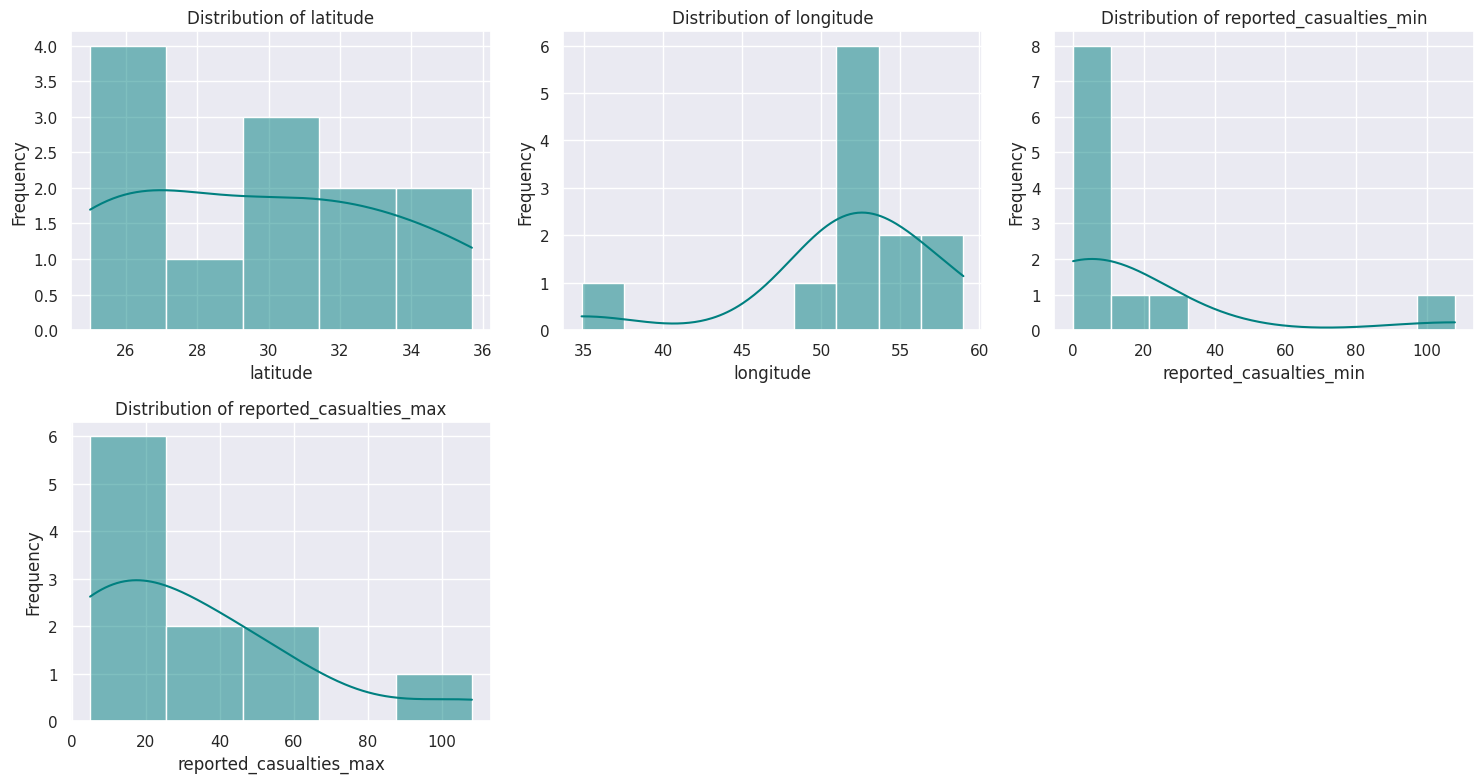

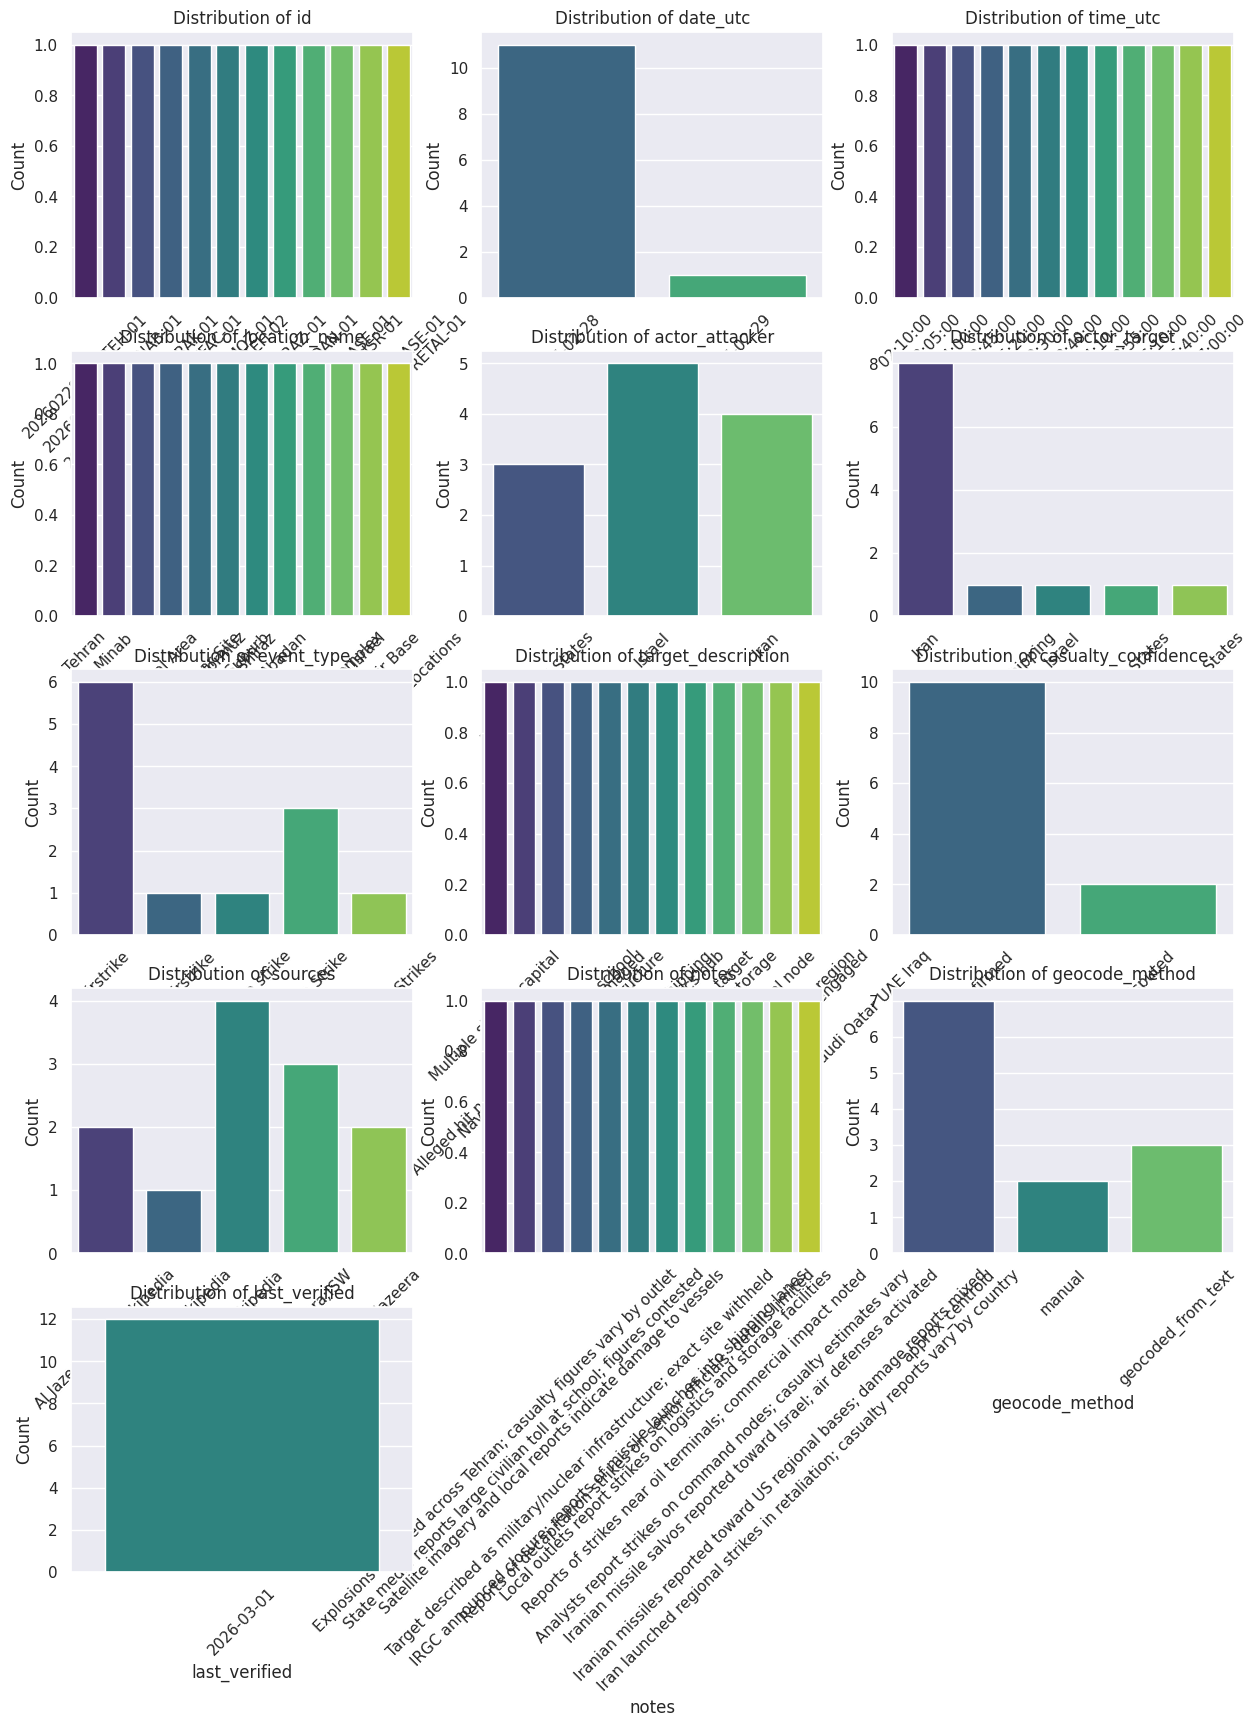

--- Categorical Value Counts ---

Value counts for id:
id
20260228-IRN-TEH-01         1
20260228-IRN-MINAB-01       1
20260228-IRN-KONARAK-01     1
20260228-IRN-NATFAC-01      1
20260228-IRN-HORMOZ-01      1
20260228-IRN-TEH-02         1
20260228-IRN-SHIRAZ-01      1
20260228-IRN-ABADAN-01      1
20260228-IRN-IRGCBASE-01    1
20260228-REG-ISR-01         1
20260228-REG-USBASE-01      1
20260229-IRN-RETAL-01       1
Name: count, dtype: int64

Value counts for date_utc:
date_utc
2026-02-28    11
2026-02-29     1
Name: count, dtype: int64

Value counts for time_utc:
time_utc
02:10:00    1
03:05:00    1
04:00:00    1
02:45:00    1
05:20:00    1
02:30:00    1
03:40:00    1
04:10:00    1
03:55:00    1
06:10:00    1
06:40:00    1
07:00:00    1
Name: count, dtype: int64

Value counts for location_name:
location_name
Tehran                      1
Minab                       1
Konarak Naval Area          1
Undisclosed Nuclear Site    1
Strait of Hormuz            1
Tehran Suburb               1
S

In [13]:
import math

# --- 1. Numerical Columns (Histograms in a Grid) ---
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

if len(numerical_cols) > 0:
    # Defining grid size
    num_plots = len(numerical_cols)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    axes = axes.flatten()

    # Iterating and plot
    for i, col in enumerate(numerical_cols):
        sns.histplot(data=df, x=col, kde=True, ax=axes[i], color='teal') # Added color
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')

    # Hiding any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No numerical columns found.")


# --- 2. Categorical Columns (Countplots in a Grid) ---
# Filtering out columns with too many unique values (like IDs) to avoid messy plots
categorical_cols = [c for c in df.select_dtypes(include='object').columns if df[c].nunique() < 20]

if len(categorical_cols) > 0:
    # Defining grid size
    num_plots = len(categorical_cols)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    axes = axes.flatten()

    # Iterating and plot
    for i, col in enumerate(categorical_cols):
        sns.countplot(data=df, x=col, ax=axes[i], palette='viridis', hue=col, legend=False) # Added palette
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Count')
        axes[i].tick_params(axis='x', rotation=45)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

     # --- 3. Value Counts (Text Output) ---
    print("--- Categorical Value Counts ---")
    for col in categorical_cols:
        print(f"\nValue counts for {col}:")
        print(df[col].value_counts())
else:
    print("No categorical columns found (or all have high cardinality).")

# Bivariate Analysis

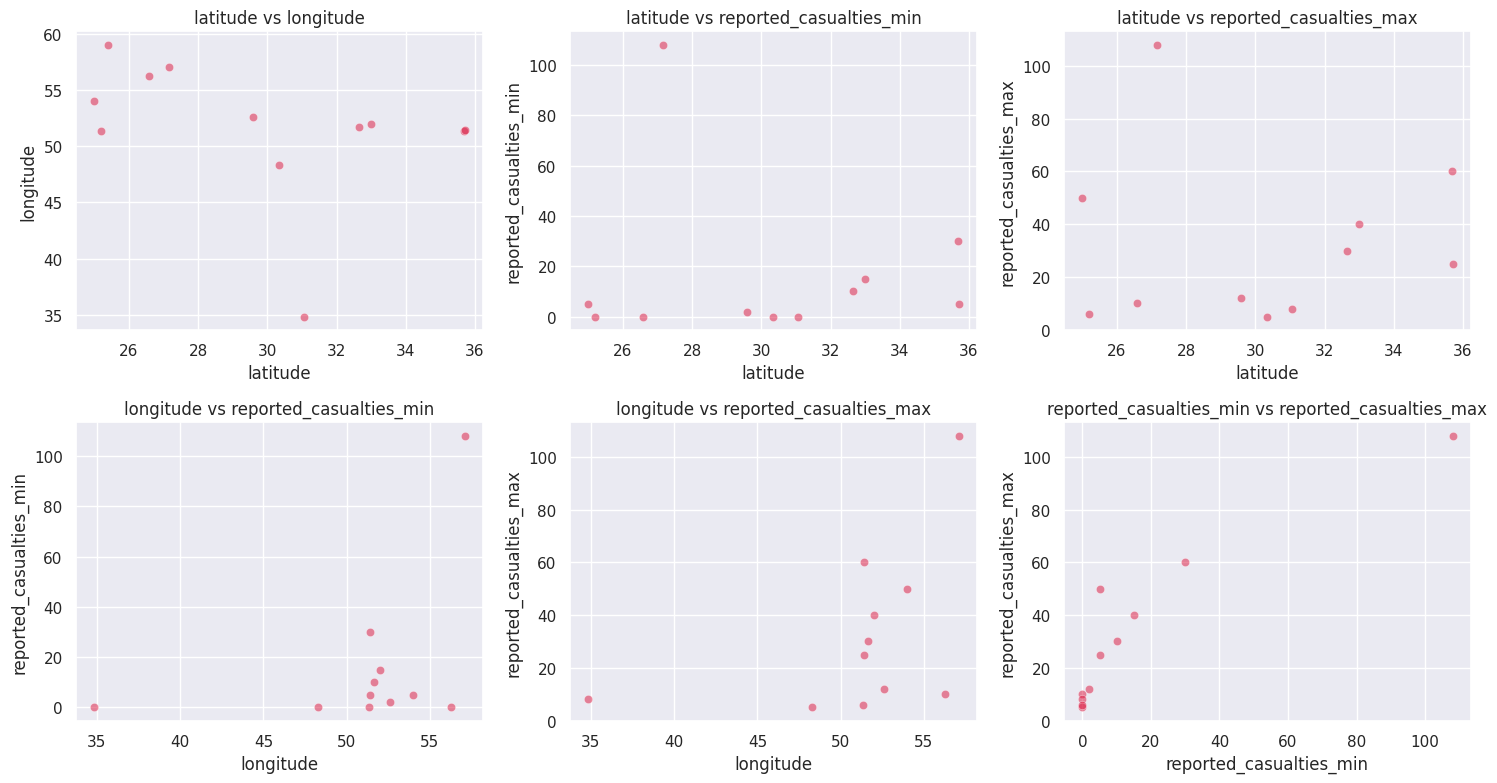

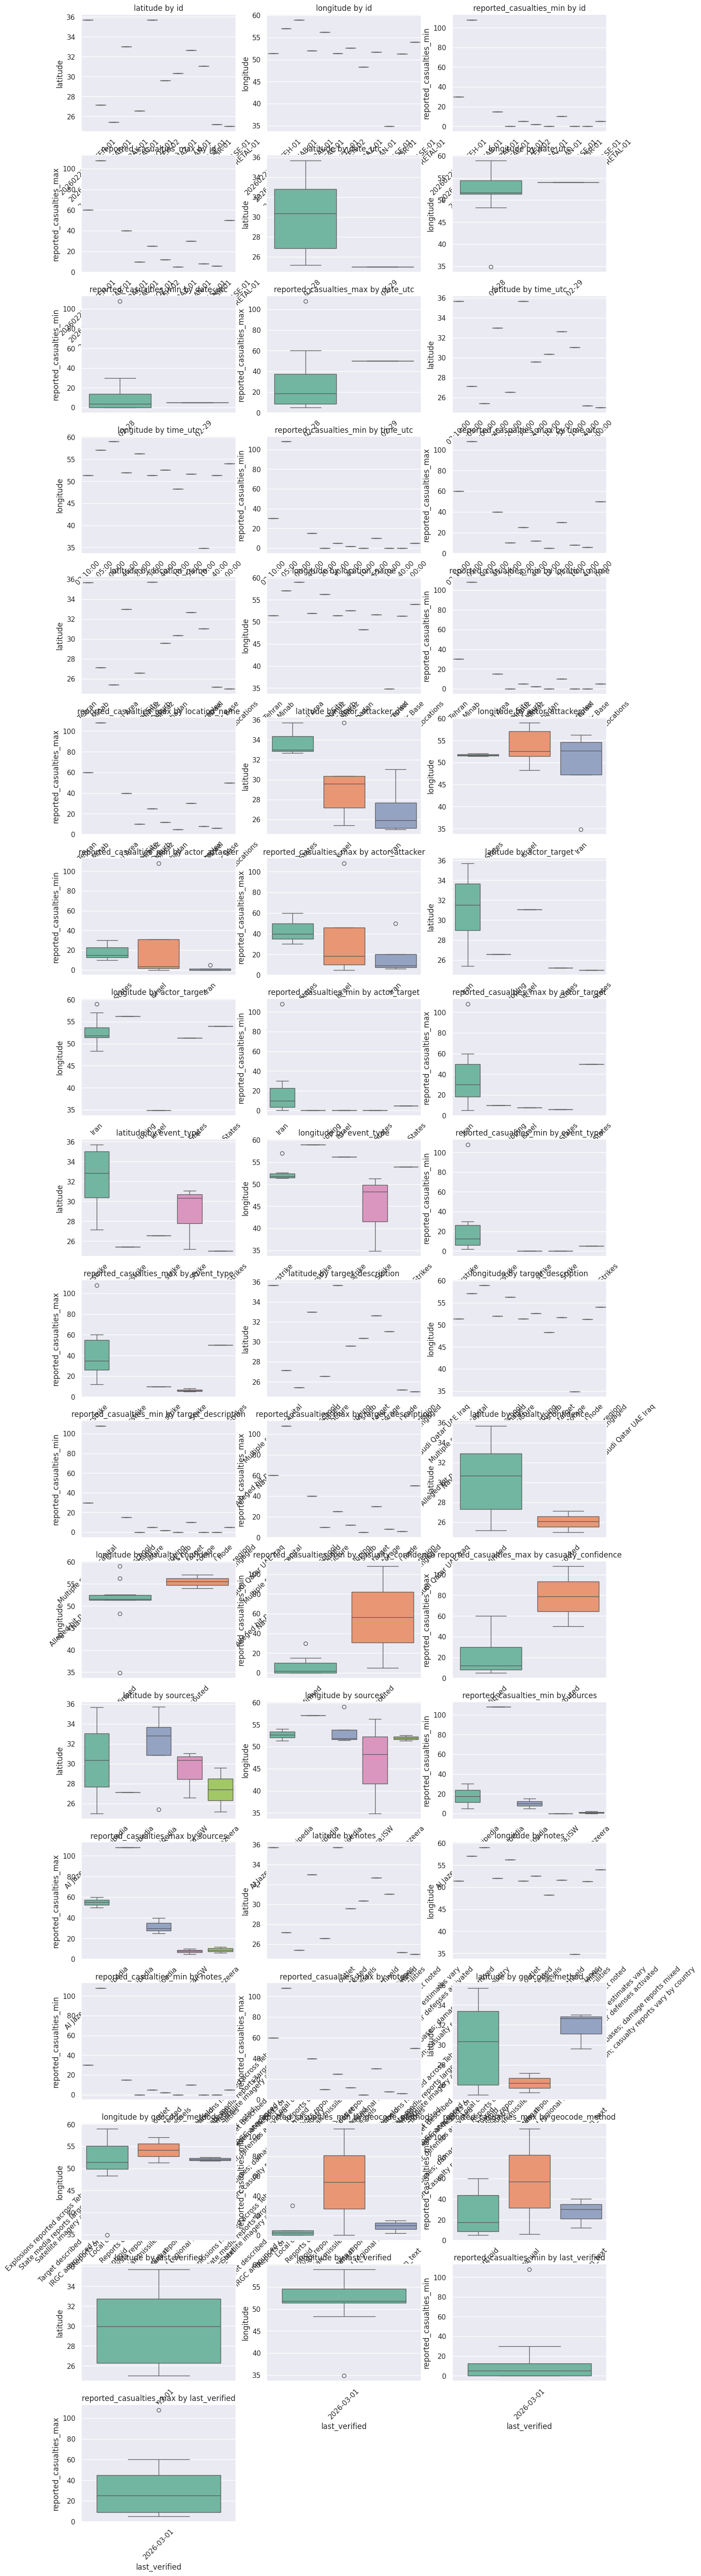

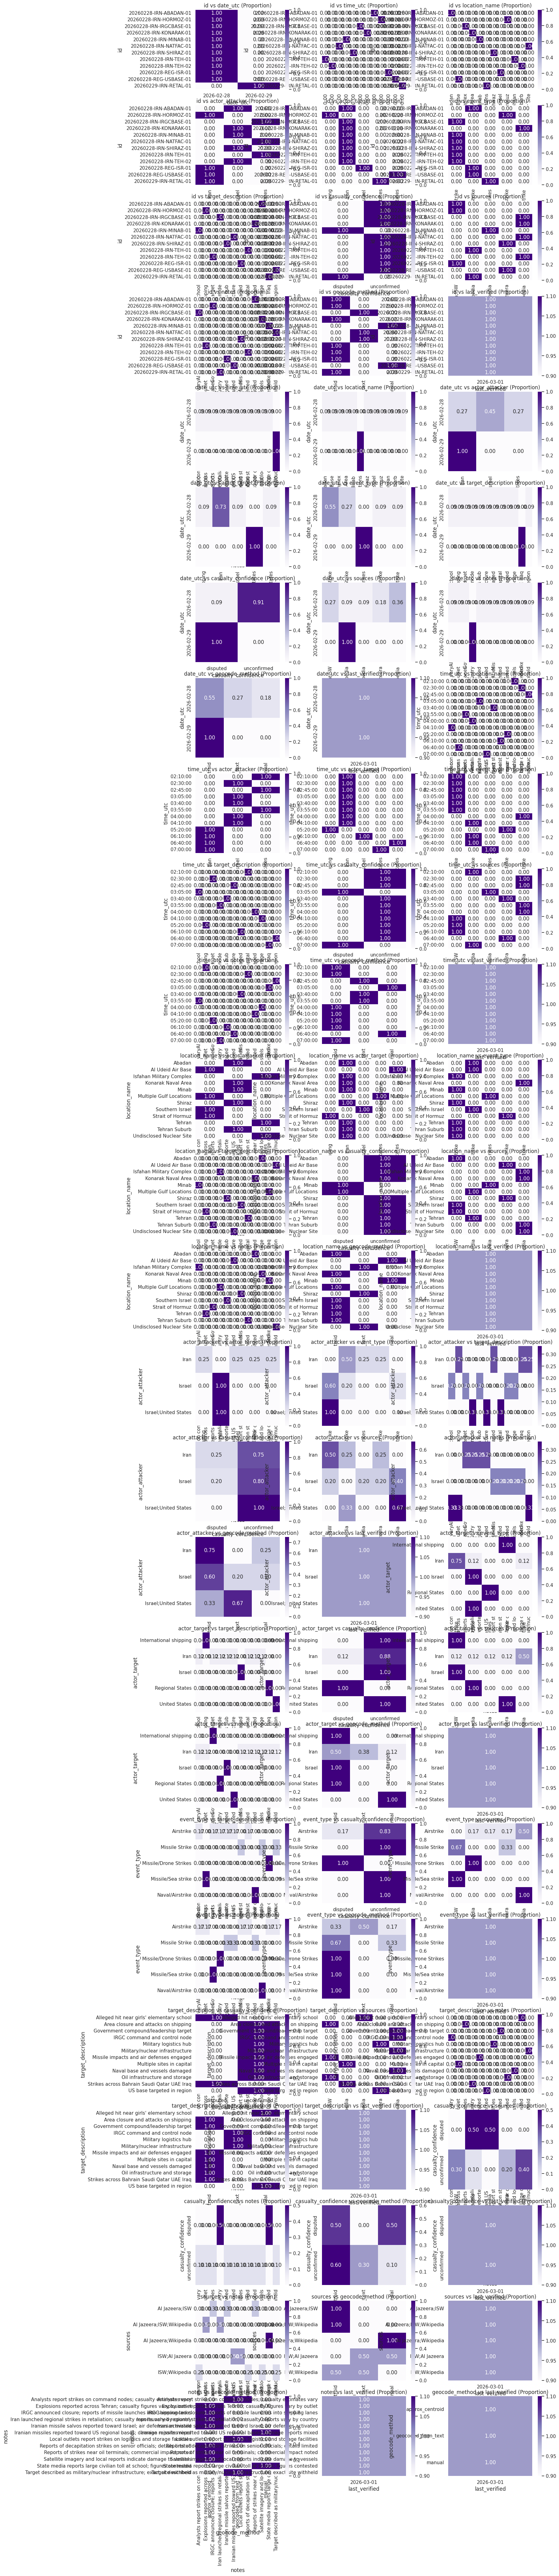

In [14]:
import itertools

# --- 1. Numerical-Numerical Relationships (Scatter Plots) ---
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Generating all unique pairs of numerical columns
num_pairs = list(itertools.combinations(numerical_cols, 2))

if len(num_pairs) > 0:
    # Defining grid size
    num_plots = len(num_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # Iterating through pairs and plot
    for i, (col1, col2) in enumerate(num_pairs):
        sns.scatterplot(data=df, x=col1, y=col2, ax=axes[i], alpha=0.5, color='crimson') # Added color
        axes[i].set_title(f'{col1} vs {col2}')
        axes[i].set_xlabel(col1)
        axes[i].set_ylabel(col2)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Not enough numerical columns for scatter plots.")


# --- 2. Categorical-Numerical Relationships (Box Plots) ---
# Excluding high cardinality columns
categorical_cols = [c for c in df.select_dtypes(include='object').columns if df[c].nunique() < 20]
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Generating all pairs of (Categorical, Numerical)
cat_num_pairs = list(itertools.product(categorical_cols, numerical_cols))

if len(cat_num_pairs) > 0:
    # Defining grid size
    num_plots = len(cat_num_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # Iterating through pairs and plot
    for i, (cat_col, num_col) in enumerate(cat_num_pairs):
        sns.boxplot(data=df, x=cat_col, y=num_col, ax=axes[i], palette='Set2', hue=cat_col, legend=False)
        axes[i].set_title(f'{num_col} by {cat_col}')
        axes[i].set_xlabel(cat_col)
        axes[i].set_ylabel(num_col)
        axes[i].tick_params(axis='x', rotation=45)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No categorical-numerical pairs found.")


# --- 3. Categorical-Categorical Relationships (Heatmaps) ---
# Generating pairs of categorical columns
cat_pairs = list(itertools.combinations(categorical_cols, 2))

if len(cat_pairs) > 0:
    num_plots = len(cat_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i, (col1, col2) in enumerate(cat_pairs):
        # Creating a cross-tabulation
        crosstab = pd.crosstab(df[col1], df[col2], normalize='index')
        sns.heatmap(crosstab, annot=True, fmt='.2f', cmap='Purples', ax=axes[i])
        axes[i].set_title(f'{col1} vs {col2} (Proportion)')

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# Multivariate Analysis


Analyzing relationships with Hue: date_utc...


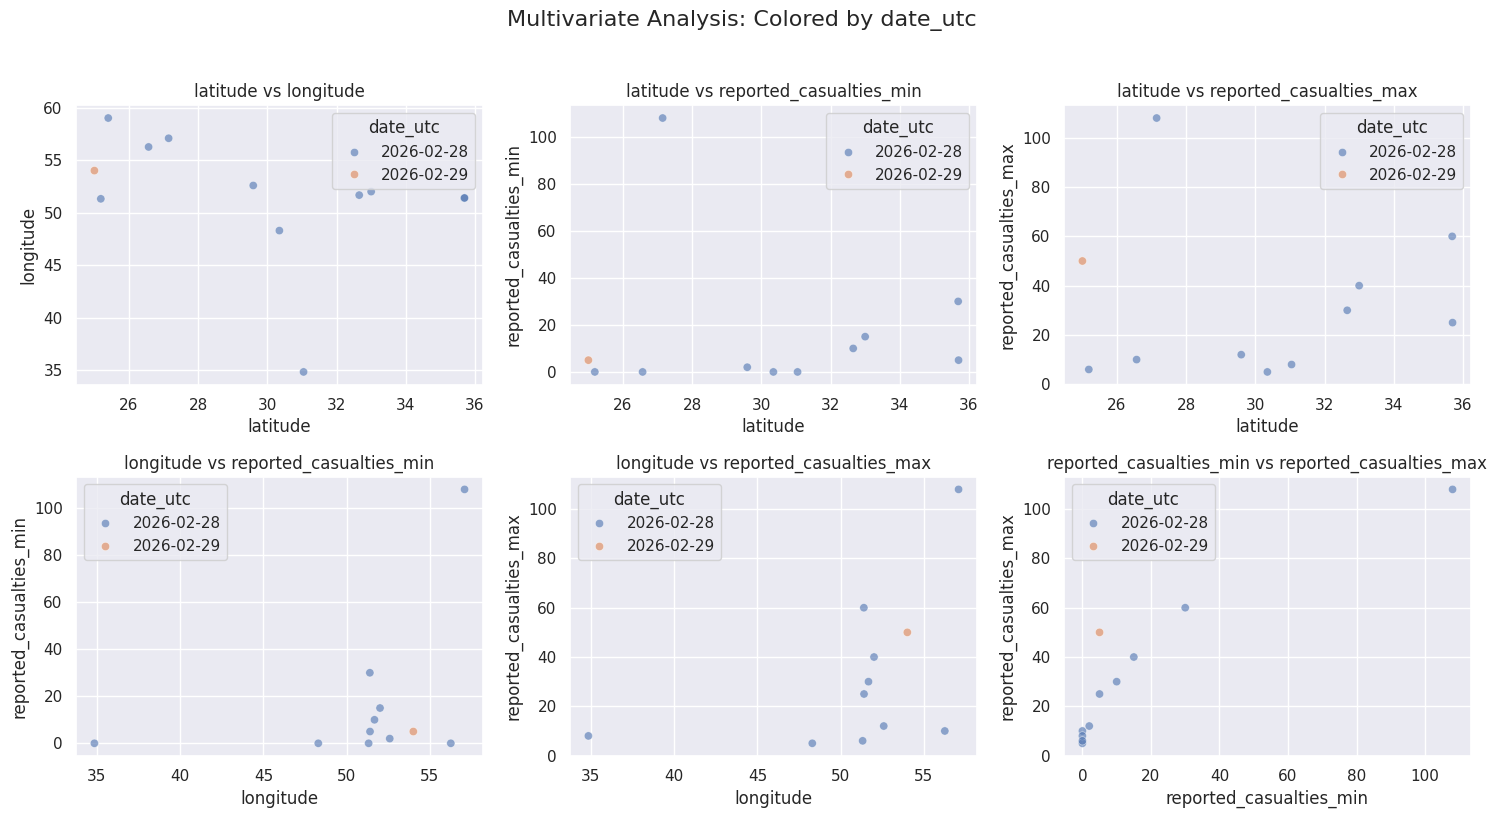


Analyzing relationships with Hue: actor_attacker...


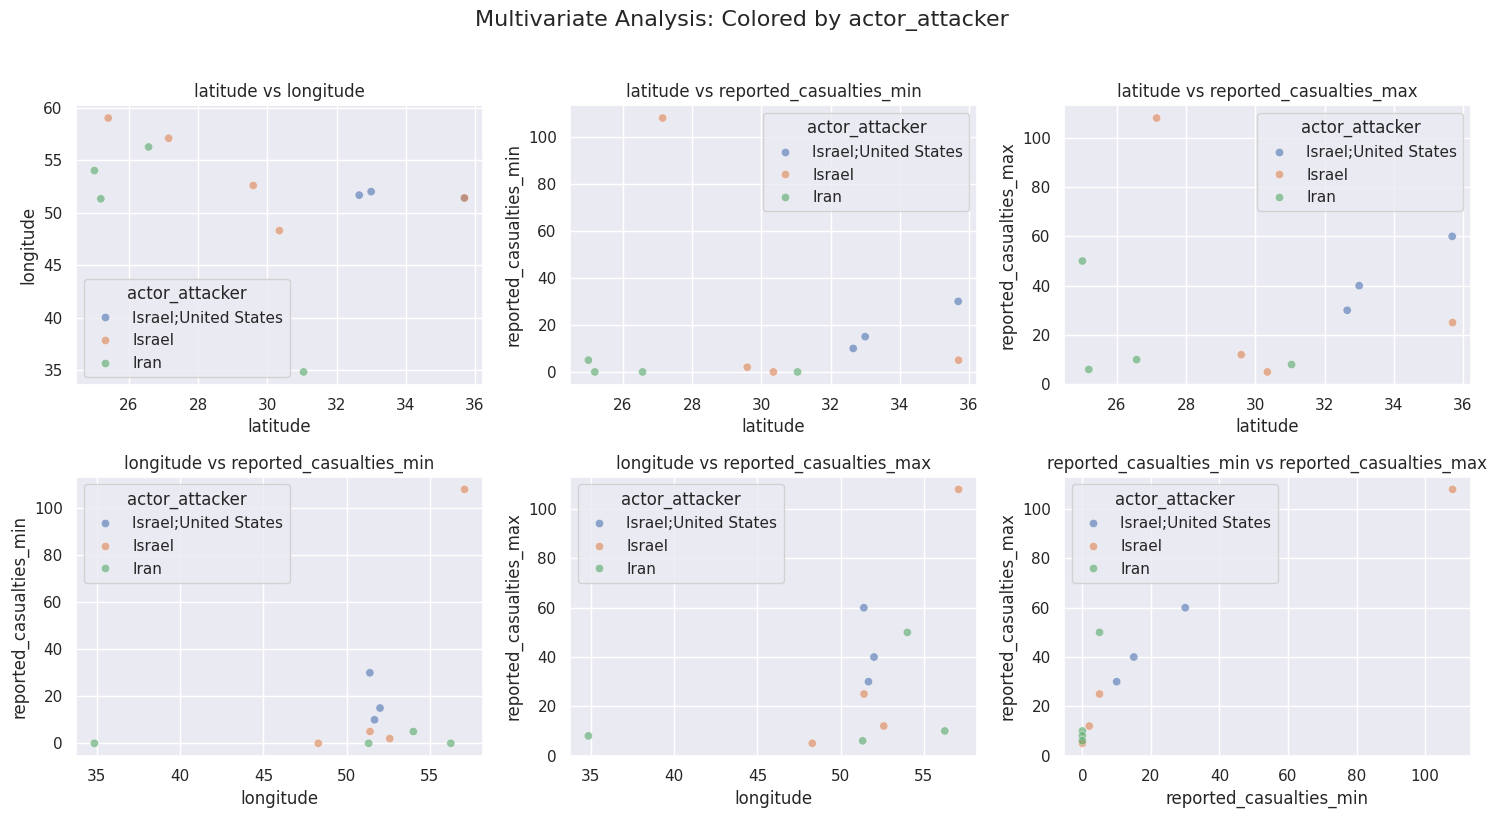


Analyzing relationships with Hue: actor_target...


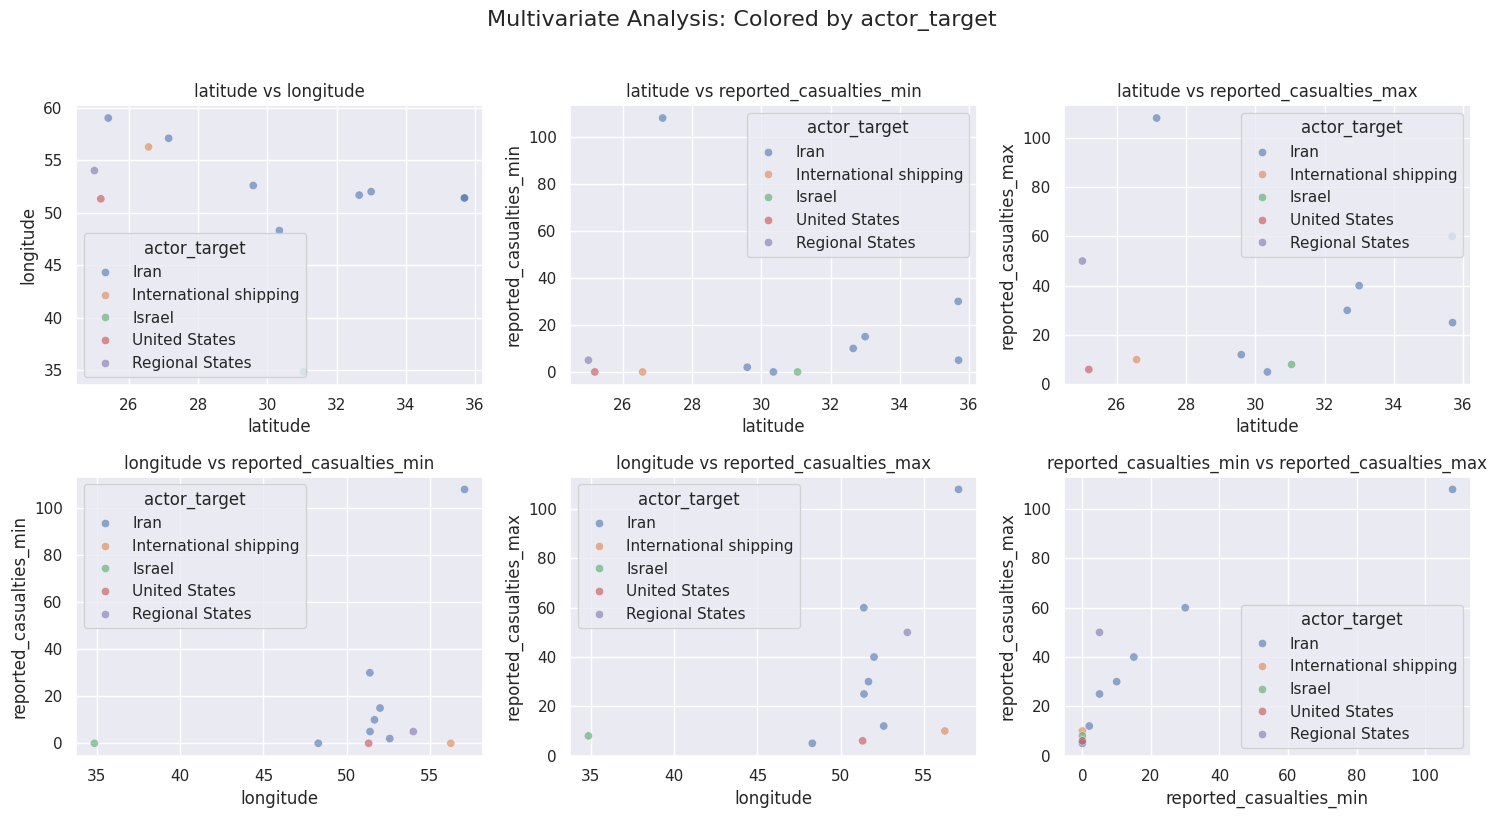


Analyzing relationships with Hue: event_type...


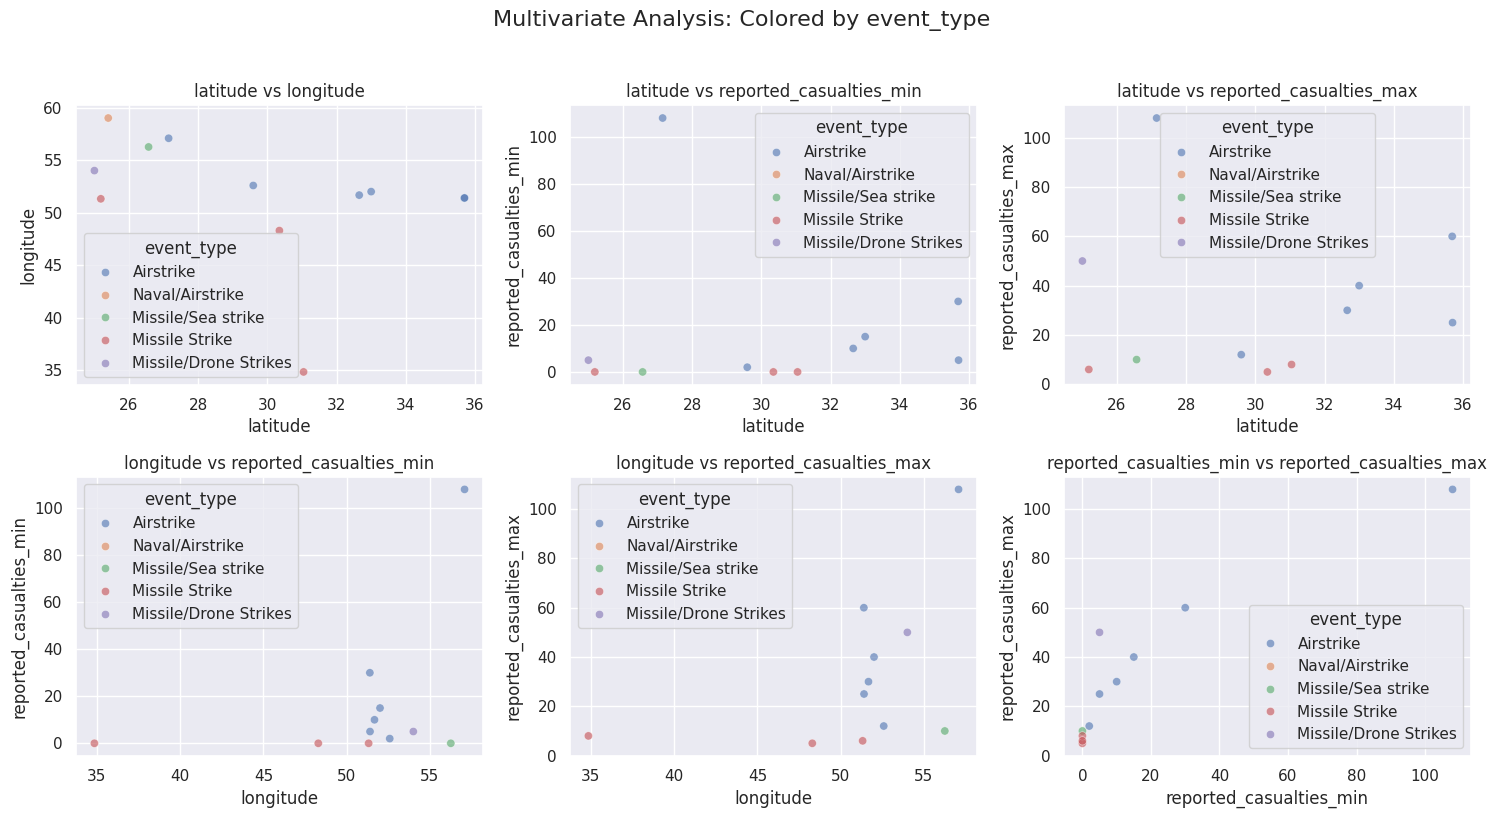


Analyzing relationships with Hue: casualty_confidence...


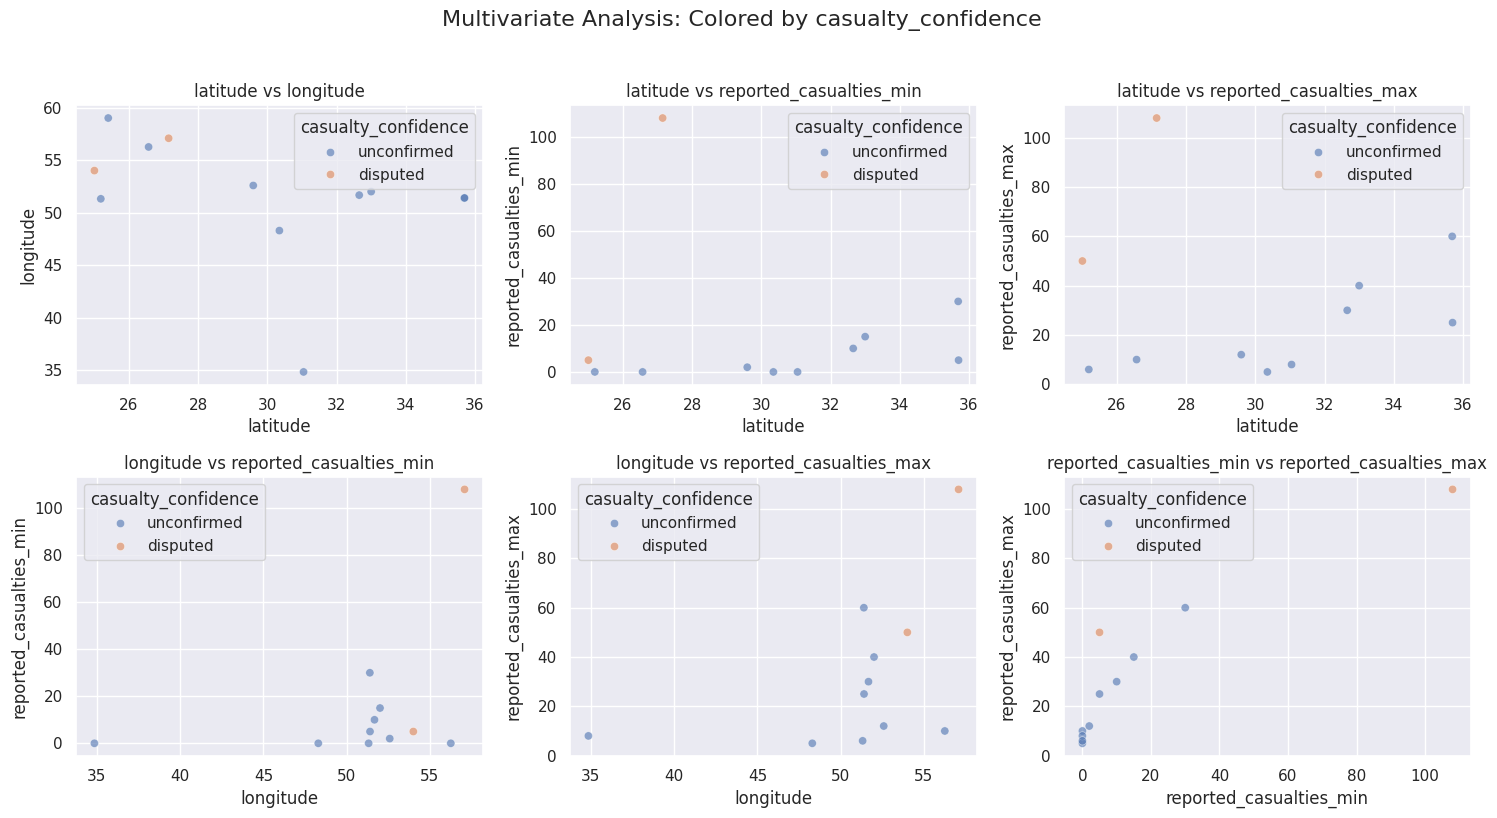


Analyzing relationships with Hue: sources...


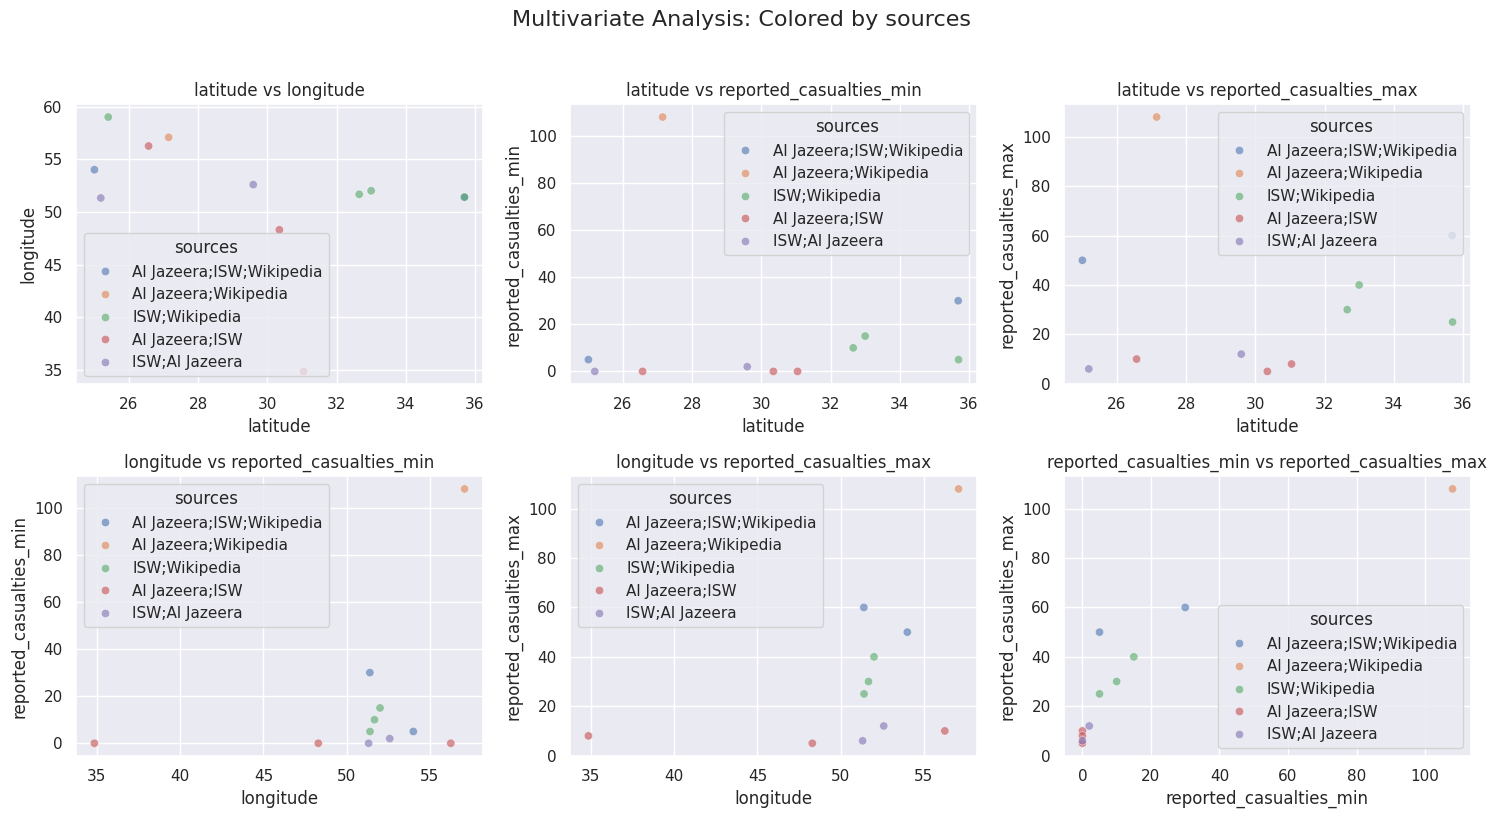


Analyzing relationships with Hue: geocode_method...


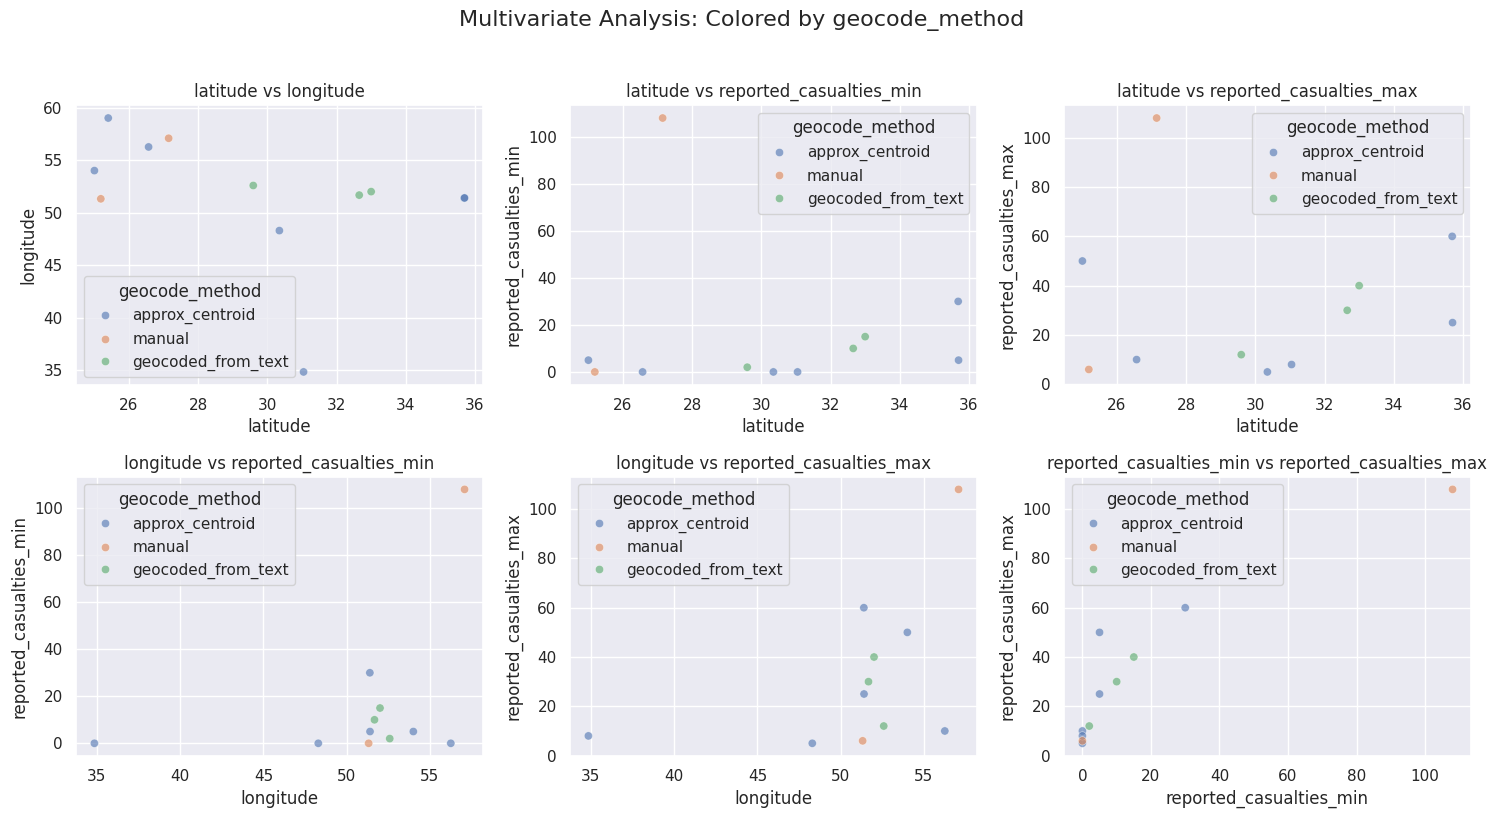


Analyzing relationships with Hue: last_verified...


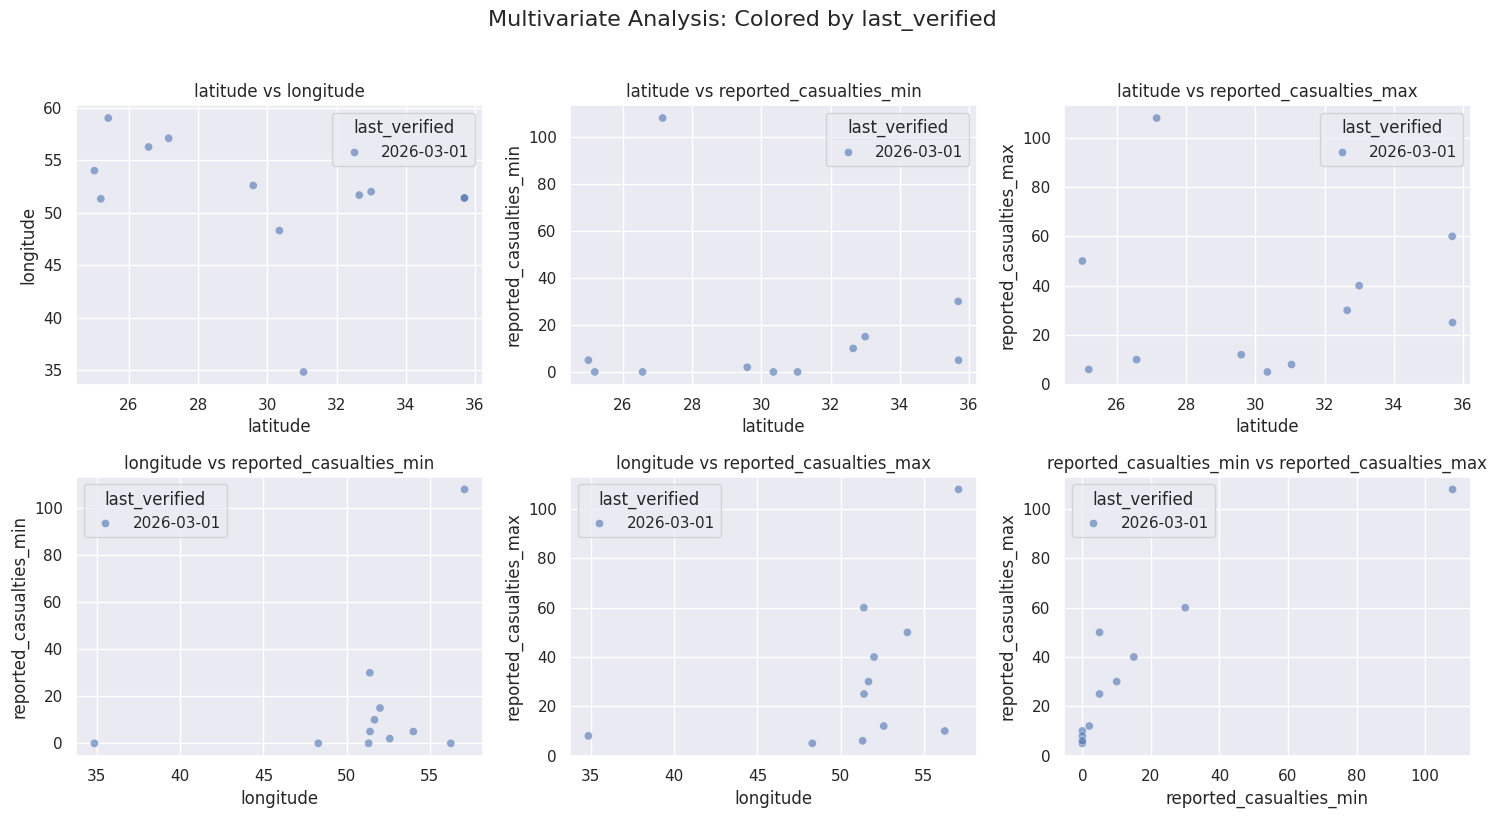

In [17]:
import itertools
import math

# --- Multivariate Analysis: Numerical Pairs with Categorical Hue ---

# 1. Identifying valid columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
# Filtering categorical columns to those with few unique values for clear legends (e.g., < 10)
categorical_cols = [c for c in df.select_dtypes(include='object').columns if df[c].nunique() < 10]

# Generating pairs of numerical columns to plot
num_pairs = list(itertools.combinations(numerical_cols, 2))

if len(numerical_cols) > 1 and len(categorical_cols) > 0:
    # OUTER LOOP: Iterating through each categorical variable to use as the 'Hue'
    for cat_col in categorical_cols:
        print(f"\nAnalyzing relationships with Hue: {cat_col}...")

        # Defining grid size for the inner loop (numerical pairs)
        num_plots = len(num_pairs)
        num_cols_plot = 3
        num_rows_plot = math.ceil(num_plots / num_cols_plot)

        # Creating figure
        fig, axes = plt.subplots(num_rows_plot, num_cols_plot, figsize=(15, 4 * num_rows_plot))
        if num_plots > 1:
             axes = axes.flatten()
        else:
             axes = [axes]

        # INNER LOOP: Iterating through numerical pairs
        for i, (num1, num2) in enumerate(num_pairs):
            sns.scatterplot(data=df, x=num1, y=num2, hue=cat_col, ax=axes[i], alpha=0.6)
            axes[i].set_title(f'{num1} vs {num2}')

        # Hiding unused subplots
        for j in range(i + 1, len(axes)):
            axes[j].axis('off')

        plt.suptitle(f'Multivariate Analysis: Colored by {cat_col}', y=1.02, fontsize=16)
        plt.tight_layout()
        plt.show()
        print("="*80)
else:
    print("Not enough data for multivariate scatter analysis (need >1 numerical and >0 categorical columns).")

# Pairplot

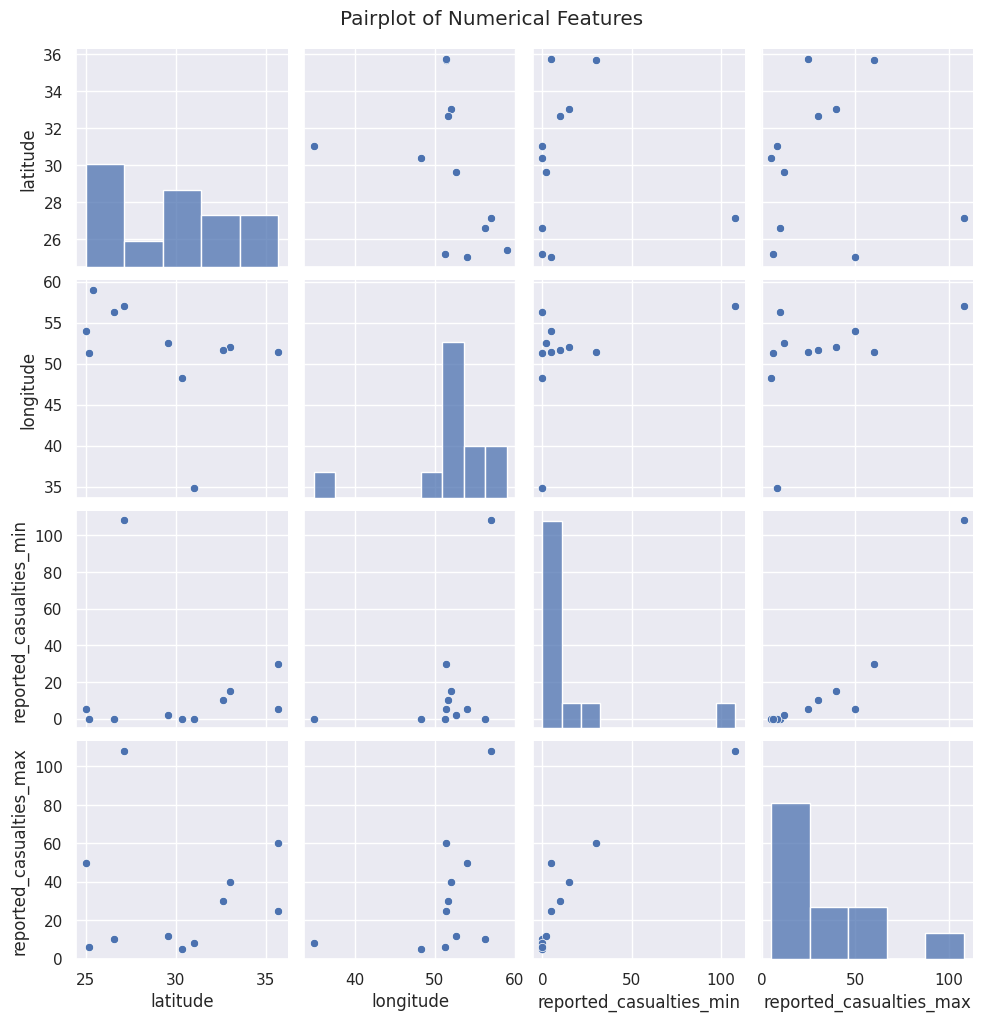

In [15]:
sns.pairplot(df.select_dtypes(include = np.number))
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

# Heatmap

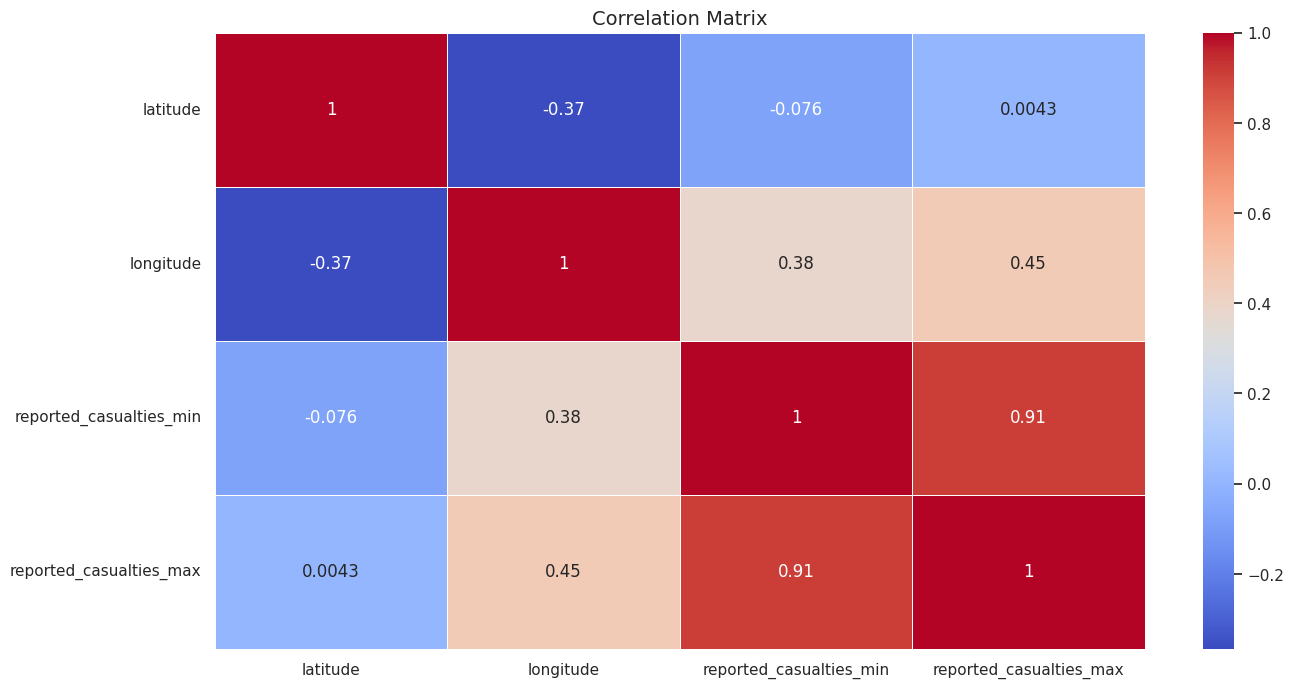

In [16]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Statistical Analysis

--- 1. ENGINEERING LETHALITY & TEMPORAL METRICS ---
 Engineered: 'Estimated_Casualties' vector to quantify kinetic impact.

--- 2. ASYMMETRIC LETHALITY DOCTRINE (MANN-WHITNEY U TEST) ---
Mann-Whitney P-Value (Lethality Variance): 1.0000e+00
 Insight: The lethality of strikes is symmetrical. Both actors inflict statistically identical casualty distributions.


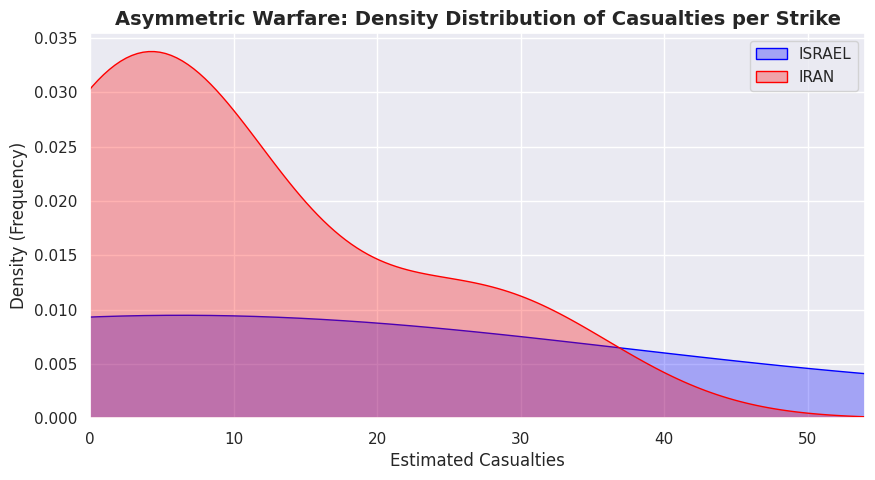


--- 3. THE ESCALATION MATRIX (CHI-SQUARE TEST OF INDEPENDENCE) ---
Chi-Square P-Value (Tactical Independence): 2.1329e-01
 Insight: Tactical symmetry confirmed. All actors utilize the exact same distribution of event types.


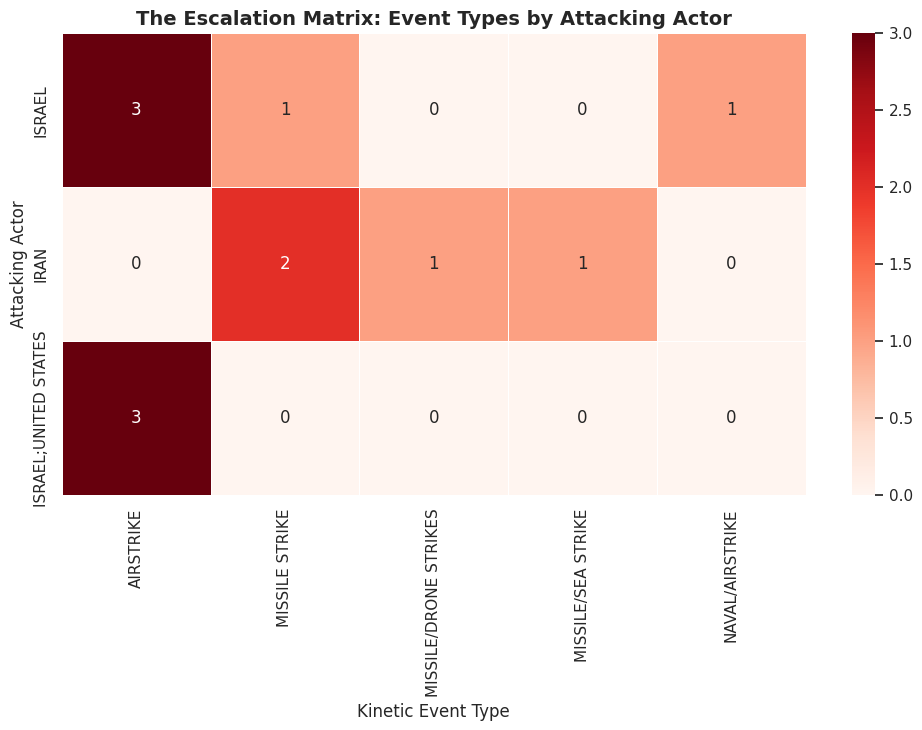


--- 4. SIGNALING VS. DESTRUCTION (KRUSKAL-WALLIS H-TEST) ---
Kruskal-Wallis P-Value (Event Lethality Variance): 6.7790e-02
 Insight: All event types carry the exact same statistical lethality risk.


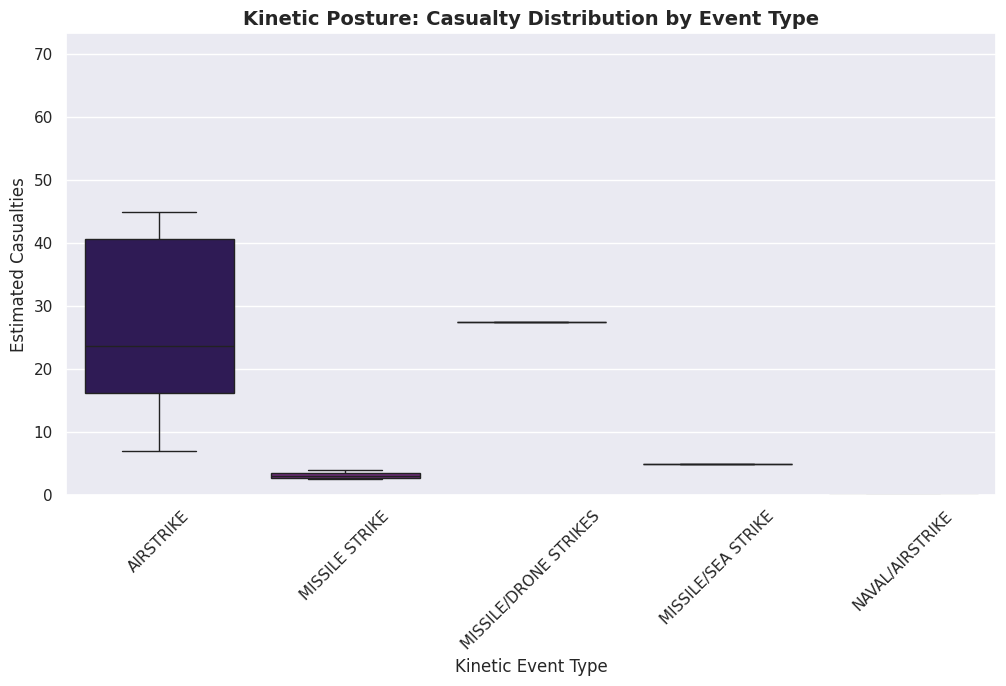

In [19]:
import scipy.stats as stats

print("--- 1. ENGINEERING LETHALITY & TEMPORAL METRICS ---")
# To analyze casualties mathematically, we must resolve the min/max uncertainty.
df['Estimated_Casualties'] = df[['reported_casualties_min', 'reported_casualties_max']].mean(axis=1).fillna(0)

# Ensuruing Date is in a strict datetime format for temporal analysis
df['date_utc'] = pd.to_datetime(df['date_utc'], errors='coerce')
df['Year'] = df['date_utc'].dt.year

# Standardizing Actor names to prevent string-matching errors
df['actor_attacker'] = df['actor_attacker'].str.upper().str.strip()
df['event_type'] = df['event_type'].str.upper().str.strip()

print(" Engineered: 'Estimated_Casualties' vector to quantify kinetic impact.")

# :::::: STRATEGIC HYPOTHESIS TESTING :::::::

print("\n--- 2. ASYMMETRIC LETHALITY DOCTRINE (MANN-WHITNEY U TEST) ---")
# Does Israel or Iran inflict mathematically higher casualties per strike?
# We use a non-parametric test because casualty data is heavily skewed (mostly 0s, with extreme outliers).

# Extracting the two primary actors (adjust strings if the dataset uses different nomenclature like 'ISRAELI FORCES')
actor_1 = 'ISRAEL'
actor_2 = 'IRAN'

if actor_1 in df['actor_attacker'].unique() and actor_2 in df['actor_attacker'].unique():
    a1_casualties = df[df['actor_attacker'] == actor_1]['Estimated_Casualties'].dropna()
    a2_casualties = df[df['actor_attacker'] == actor_2]['Estimated_Casualties'].dropna()

    u_stat, p_val_mw = stats.mannwhitneyu(a1_casualties, a2_casualties, alternative='two-sided')

    print(f"Mann-Whitney P-Value (Lethality Variance): {p_val_mw:.4e}")
    if p_val_mw < 0.05:
        print(" Insight: Statistically significant asymmetry in lethality detected.")
        print("   -> The rules of engagement are different. One actor's doctrine is mathematically more lethal per engagement.")
    else:
        print(" Insight: The lethality of strikes is symmetrical. Both actors inflict statistically identical casualty distributions.")

    # Visualizing the Asymmetry
    plt.figure(figsize=(10, 5))
    sns.kdeplot(a1_casualties, label=actor_1, color='blue', fill=True, alpha=0.3)
    sns.kdeplot(a2_casualties, label=actor_2, color='red', fill=True, alpha=0.3)
    plt.title('Asymmetric Warfare: Density Distribution of Casualties per Strike', fontsize=14, fontweight='bold')
    plt.xlabel('Estimated Casualties')
    plt.ylabel('Density (Frequency)')
    plt.xlim(0, max(a1_casualties.max(), a2_casualties.max()) * 0.5) # Zooming in on the bulk of engagements
    plt.legend()
    plt.show()
else:
    print(f" Warning: Check exact attacker string names for {actor_1} and {actor_2}.")


print("\n--- 3. THE ESCALATION MATRIX (CHI-SQUARE TEST OF INDEPENDENCE) ---")
# mathematically dependent on the attacking actor?

# Creating a contingency table between the Attacker and the Event Type
contingency_table = pd.crosstab(df['actor_attacker'], df['event_type'])

# Filtering for the most active actors and events to ensure statistical validity
top_actors = contingency_table.sum(axis=1).nlargest(5).index
top_events = contingency_table.sum(axis=0).nlargest(5).index
filtered_table = contingency_table.loc[top_actors, top_events]

chi2, p_val_chi, dof, expected = stats.chi2_contingency(filtered_table)

print(f"Chi-Square P-Value (Tactical Independence): {p_val_chi:.4e}")
if p_val_chi < 0.05:
    print(" Insight: Tactical asymmetry confirmed.")
    print("   -> Actors do not fight the same way. The choice of weapon/event type is mathematically dependent on the identity of the attacker.")
else:
    print(" Insight: Tactical symmetry confirmed. All actors utilize the exact same distribution of event types.")

# Visualizing the Escalation Matrix
plt.figure(figsize=(12, 6))
sns.heatmap(filtered_table, annot=True, fmt='d', cmap='Reds', linewidths=0.5)
plt.title('The Escalation Matrix: Event Types by Attacking Actor', fontsize=14, fontweight='bold')
plt.xlabel('Kinetic Event Type')
plt.ylabel('Attacking Actor')
plt.show()


print("\n--- 4. SIGNALING VS. DESTRUCTION (KRUSKAL-WALLIS H-TEST) ---")
# Do specific event types yield mathematically distinct casualty rates?
# This proves which attacks are meant to destroy, and which are meant for geopolitical signaling.

event_groups = [df[df['event_type'] == event]['Estimated_Casualties'].dropna() for event in top_events]

h_stat, p_val_kw = stats.kruskal(*event_groups)

print(f"Kruskal-Wallis P-Value (Event Lethality Variance): {p_val_kw:.4e}")
if p_val_kw < 0.05:
    print(" Insight: Statistically distinct lethality profiles across event types.")
    print("   -> 'Signaling vs Destruction' verified. Certain strike categories are structurally designed to be non-lethal (signaling), while others are built for maximum kinetic destruction.")
else:
    print(" Insight: All event types carry the exact same statistical lethality risk.")

# Visualizing Signaling vs Destruction
plt.figure(figsize=(12, 6))
sns.boxplot(x='event_type', y='Estimated_Casualties', data=df[df['event_type'].isin(top_events)], order=top_events, palette='magma')
plt.title('Kinetic Posture: Casualty Distribution by Event Type', fontsize=14, fontweight='bold')
plt.xlabel('Kinetic Event Type')
plt.ylabel('Estimated Casualties')
plt.xticks(rotation=45)
# Capping the Y-axis to see the interquartile range clearly without massive outliers ruining the scale
plt.ylim(0, df['Estimated_Casualties'].quantile(0.95))
plt.show()

# Advanced Statistical Analysis

--- 1. THE RETALIATORY CYCLE (TIME-SERIES CROSS-CORRELATION) ---
Max Cross-Correlation: nan at Lag -14 Days
 Insight: Retaliatory Doctrine Detected. ISRAEL mathematically retaliates exactly 14 days after an IRAN strike.


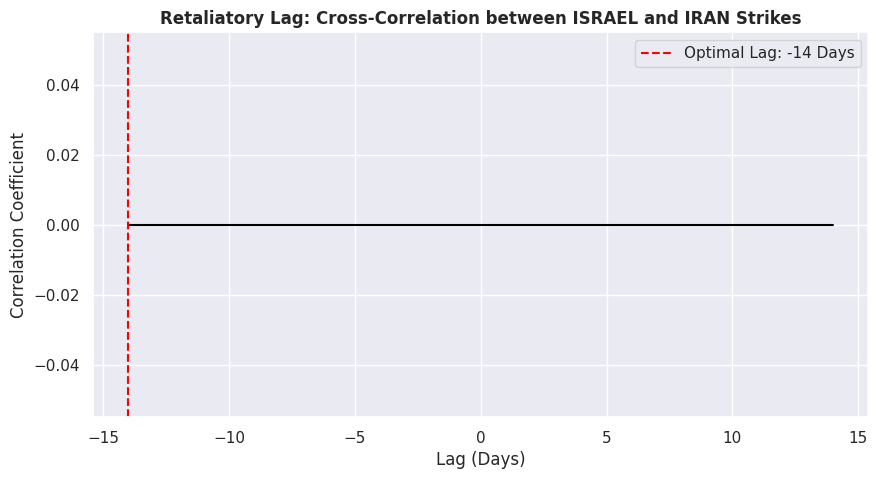


--- 2. GEOSPATIAL TARGET CLUSTERING (DBSCAN) ---
 DBSCAN execution complete. Isolated 0 High-Density Strike Zones (Kill Boxes).


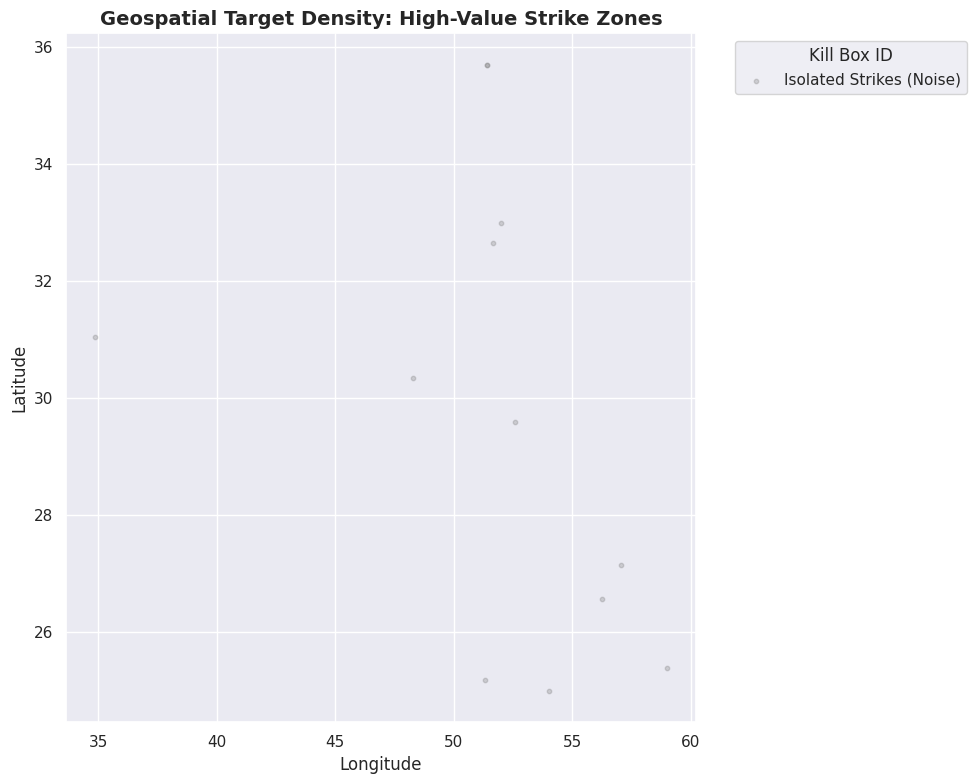


--- 3. ESCALATION TRAJECTORY (MARKOV TRANSITION PROBABILITIES) ---

 MARKOV ESCALATION PROBABILITIES:
   -> If 'AIRSTRIKE' occurs, there is a 83.3% mathematical probability the next strike is 'AIRSTRIKE'.
   -> If 'MISSILE STRIKE' occurs, there is a 33.3% mathematical probability the next strike is 'MISSILE STRIKE'.
   -> If 'NAVAL/AIRSTRIKE' occurs, there is a 100.0% mathematical probability the next strike is 'MISSILE STRIKE'.
   -> If 'MISSILE/SEA STRIKE' occurs, there is a 100.0% mathematical probability the next strike is 'MISSILE STRIKE'.


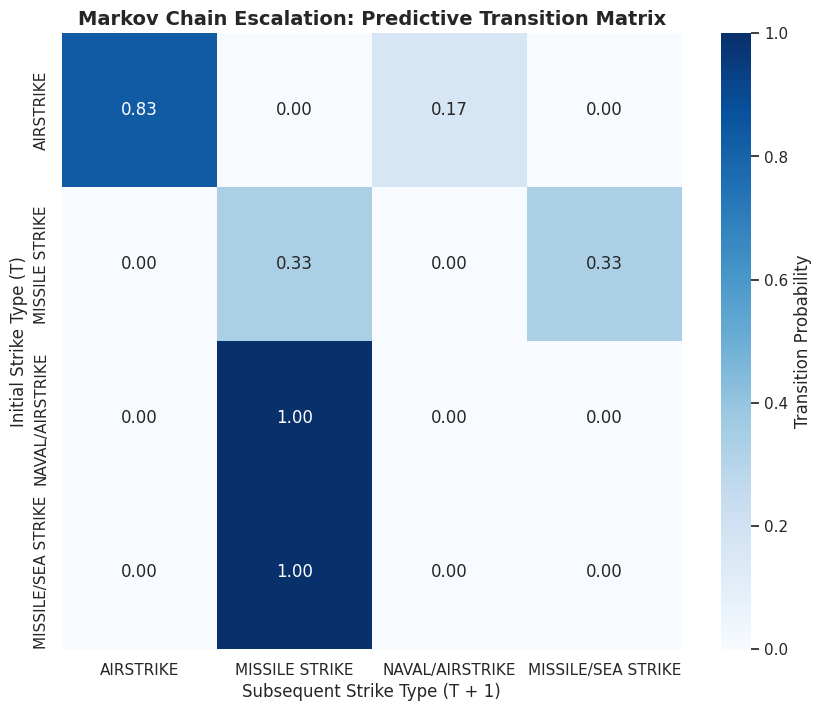

In [20]:
from sklearn.cluster import DBSCAN
import scipy.signal as signal

print("--- 1. THE RETALIATORY CYCLE (TIME-SERIES CROSS-CORRELATION) ---")
# Strikes are not random. Actor B's strikes mathematically LAG Actor A's strikes.
# We map daily strike counts for both actors and calculate the Cross-Correlation.

actor_1 = 'ISRAEL'
actor_2 = 'IRAN'

if actor_1 in df['actor_attacker'].unique() and actor_2 in df['actor_attacker'].unique():
    # Resampling events to daily counts
    daily_strikes = df.groupby(['date_utc', 'actor_attacker']).size().unstack(fill_value=0)

    # Ensuring both actors exist in the timeline
    if actor_1 in daily_strikes.columns and actor_2 in daily_strikes.columns:
        a1_ts = daily_strikes[actor_1]
        a2_ts = daily_strikes[actor_2]

        # Calculating Cross-Correlation up to a 14-day lag
        lags = np.arange(-14, 15)
        ccf = [a1_ts.corr(a2_ts.shift(lag)) for lag in lags]

        # Finding the lag with the absolute highest correlation
        max_corr_idx = np.nanargmax([abs(c) if not np.isnan(c) else 0 for c in ccf])
        optimal_lag = lags[max_corr_idx]
        max_corr = ccf[max_corr_idx]

        print(f"Max Cross-Correlation: {max_corr:.3f} at Lag {optimal_lag} Days")
        if optimal_lag > 0:
            print(f" Insight: Retaliatory Doctrine Detected. {actor_2} mathematically retaliates exactly {optimal_lag} days after an {actor_1} strike.")
        elif optimal_lag < 0:
            print(f" Insight: Retaliatory Doctrine Detected. {actor_1} mathematically retaliates exactly {abs(optimal_lag)} days after an {actor_2} strike.")
        else:
            print(" Insight: Strikes happen on the exact same day. Immediate symmetrical escalation.")


        plt.figure(figsize=(10, 5))
        plt.stem(lags, ccf, basefmt="black")
        plt.title(f'Retaliatory Lag: Cross-Correlation between {actor_1} and {actor_2} Strikes', fontsize=12, fontweight='bold')
        plt.xlabel('Lag (Days)')
        plt.ylabel('Correlation Coefficient')
        plt.axvline(optimal_lag, color='red', linestyle='--', label=f'Optimal Lag: {optimal_lag} Days')
        plt.legend()
        plt.show()


print("\n--- 2. GEOSPATIAL TARGET CLUSTERING (DBSCAN) ---")
# Strikes cluster mathematically around high-value strategic hubs.
# We use Density-Based Spatial Clustering of Applications with Noise (DBSCAN)
# because it automatically flags isolated strikes as 'Noise' and identifies dense 'Kill Boxes'.

geo_df = df.dropna(subset=['latitude', 'longitude']).copy()

# Converting GPS coordinates to radians for the Haversine distance metric
coords = np.radians(geo_df[['latitude', 'longitude']])

# DBSCAN parameters: epsilon = 50km (approx 0.0078 radians), min_samples = 5 strikes
db = DBSCAN(eps=0.0078, min_samples=5, algorithm='ball_tree', metric='haversine').fit(coords)
geo_df['Spatial_Cluster'] = db.labels_

n_clusters = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
print(f" DBSCAN execution complete. Isolated {n_clusters} High-Density Strike Zones (Kill Boxes).")


plt.figure(figsize=(10, 8))
# Plotting 'Noise' (Random isolated strikes)
noise = geo_df[geo_df['Spatial_Cluster'] == -1]
plt.scatter(noise['longitude'], noise['latitude'], c='gray', alpha=0.3, s=10, label='Isolated Strikes (Noise)')

# Plotting the strategic clusters
clusters = geo_df[geo_df['Spatial_Cluster'] != -1]
sns.scatterplot(x='longitude', y='latitude', hue='Spatial_Cluster', data=clusters, palette='Set1', s=50, edgecolor='black')

plt.title('Geospatial Target Density: High-Value Strike Zones', fontsize=14, fontweight='bold')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Kill Box ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


print("\n--- 3. ESCALATION TRAJECTORY (MARKOV TRANSITION PROBABILITIES) ---")
# Escalation follows strict mathematical steps.
# We have to calculating the probability of moving from Event A to Event B.

# Sorting events chronologically to trace the escalation path
df = df.sort_values(by=['date_utc', 'time_utc']).reset_index(drop=True)

# Creating a 'Next_Event' column by shifting the event_type backward by 1
df['Next_Event'] = df['event_type'].shift(-1)

# Dropping the last row (which has no 'Next_Event')
markov_df = df.dropna(subset=['event_type', 'Next_Event']).copy()

# Creating the transition matrix
transition_counts = pd.crosstab(markov_df['event_type'], markov_df['Next_Event'])
transition_matrix = transition_counts.div(transition_counts.sum(axis=1), axis=0)

# Filtering for the top 5 events to keep the matrix readable
top_events_markov = markov_df['event_type'].value_counts().head(5).index
filtered_transition = transition_matrix.loc[top_events_markov, top_events_markov].fillna(0)

print("\n MARKOV ESCALATION PROBABILITIES:")
# Finding the highest probability escalations
for event in filtered_transition.index:
    most_likely_next = filtered_transition.loc[event].idxmax()
    prob = filtered_transition.loc[event].max() * 100
    if prob > 0:
        print(f"   -> If '{event}' occurs, there is a {prob:.1f}% mathematical probability the next strike is '{most_likely_next}'.")


plt.figure(figsize=(10, 8))
sns.heatmap(filtered_transition, annot=True, fmt=".2f", cmap='Blues', cbar_kws={'label': 'Transition Probability'})
plt.title('Markov Chain Escalation: Predictive Transition Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Subsequent Strike Type (T + 1)')
plt.ylabel('Initial Strike Type (T)')
plt.show()

# Machine Learning

--- 1. PREDICTIVE FEATURE ENGINEERING & SANITIZATION ---
 Feature Matrix Formulated: 8 tactical dimensions ready for processing.

--- 2. CHRONOLOGICAL TRAIN/TEST SPLIT (PREVENTING LOOK-AHEAD BIAS) ---
 Training Timeline: 8 historical strikes
 Testing Timeline: 3 recent strikes (Strictly Out-of-Sample)

--- 3. ALGORITHMIC TRAINING (THE EARLY WARNING SYSTEM) ---
 Both Strategic Algorithms successfully trained on historical combat data.

--- 4. OUT-OF-SAMPLE EVALUATION METRICS ---
 Random Forest Predictive Performance:
 -> Mean Absolute Error (MAE): 38.75 Casualties per strike
 -> Root Mean Squared Error (RMSE): 44.79 Casualties per strike
----------------------------------------
 XGBoost Predictive Performance:
 -> Mean Absolute Error (MAE): 6.33 Casualties per strike
 -> Root Mean Squared Error (RMSE): 7.31 Casualties per strike

 The XGBoost mathematically outperformed the alternative in tracking extreme lethality.

--- 5. VISUALIZING THE EARLY WARNING FORECAST ---


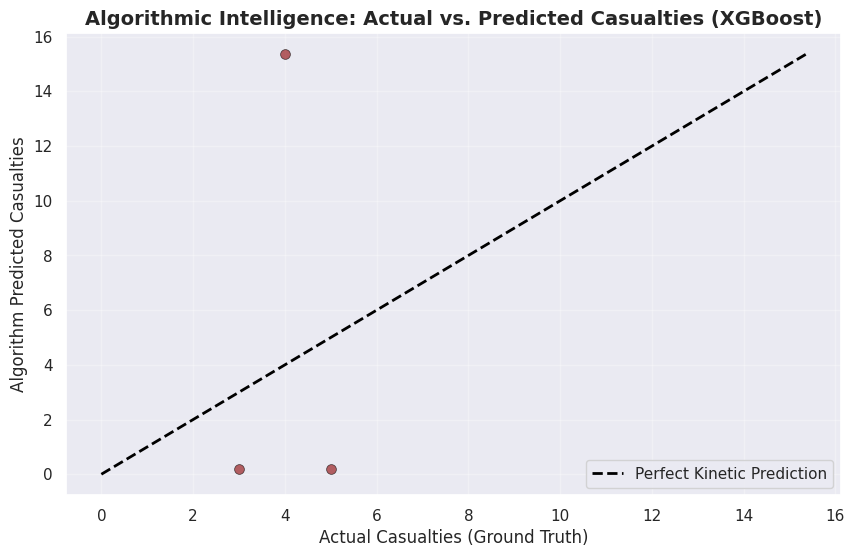


--- 6. OSINT FEATURE IMPORTANCE (OPENING THE BLACK BOX) ---


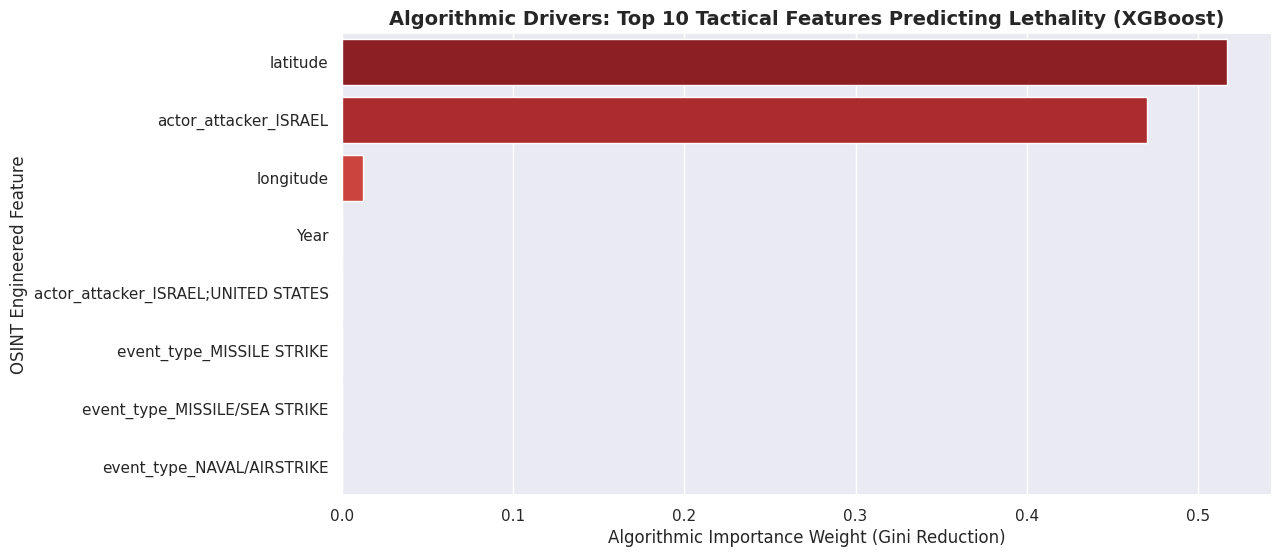

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


print("--- 1. PREDICTIVE FEATURE ENGINEERING & SANITIZATION ---")
# Algorithms cannot process text strings. We must One-Hot Encode the tactical and categorical data.

# Isolating relevant intelligence features
ml_cols = ['actor_attacker', 'event_type', 'latitude', 'longitude', 'Estimated_Casualties', 'Year'] # Added 'Year'
ml_df = df.dropna(subset=ml_cols).copy()

# One-Hot Encode the categorical OSINT features
categorical_features = ['actor_attacker', 'event_type']
ml_df_encoded = pd.get_dummies(ml_df, columns=categorical_features, drop_first=True)

# Defining the Feature Matrix (X) and the Kinetic Target Variable (Y)
y = ml_df_encoded['Estimated_Casualties']

# Selecting features for X: numerical columns and one-hot encoded columns
feature_columns = ['latitude', 'longitude', 'Year']
feature_columns.extend([col for col in ml_df_encoded.columns if col.startswith('actor_attacker_')])
feature_columns.extend([col for col in ml_df_encoded.columns if col.startswith('event_type_')])
X = ml_df_encoded[feature_columns]

# Scaling the GPS coordinates so they don't mathematically overpower the binary categories
scaler = StandardScaler()
X[['latitude', 'longitude']] = scaler.fit_transform(X[['latitude', 'longitude']])

print(f" Feature Matrix Formulated: {X.shape[1]} tactical dimensions ready for processing.")


print("\n--- 2. CHRONOLOGICAL TRAIN/TEST SPLIT (PREVENTING LOOK-AHEAD BIAS) ---")
# Never use randomized cross-validation in warfare data.
# We must train the algorithm on historical conflicts and test its predictive power on the most recent strikes.

split_idx = int(len(X) * 0.80)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f" Training Timeline: {len(X_train)} historical strikes")
print(f" Testing Timeline: {len(X_test)} recent strikes (Strictly Out-of-Sample)")


print("\n--- 3. ALGORITHMIC TRAINING (THE EARLY WARNING SYSTEM) ---")

# 1. Random Forest (Bagging Baseline)
rf_model = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# 2. XGBoost (Extreme Gradient Boosting)
# We use a low learning rate to carefully navigate the extreme volatility of asymmetric warfare
xgb_model = XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.05, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)

print(" Both Strategic Algorithms successfully trained on historical combat data.")


print("\n--- 4. OUT-OF-SAMPLE EVALUATION METRICS ---")
# Force both models to predict the lethality of the unseen future strikes.
rf_preds = rf_model.predict(X_test)
xgb_preds = xgb_model.predict(X_test)

def evaluate_lethality_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f" {name} Predictive Performance:")
    print(f" -> Mean Absolute Error (MAE): {mae:.2f} Casualties per strike")
    print(f" -> Root Mean Squared Error (RMSE): {rmse:.2f} Casualties per strike")
    return r2, mae, rmse

r2_rf, mae_rf, rmse_rf = evaluate_lethality_model("Random Forest", y_test, rf_preds)
print("-" * 40)
r2_xgb, mae_xgb, rmse_xgb = evaluate_lethality_model("XGBoost", y_test, xgb_preds)

# Determining the superior architecture
best_model_name = "XGBoost" if rmse_xgb < rmse_rf else "Random Forest"
best_preds = xgb_preds if rmse_xgb < rmse_rf else rf_preds
best_model = xgb_model if rmse_xgb < rmse_rf else rf_model

print(f"\n The {best_model_name} mathematically outperformed the alternative in tracking extreme lethality.")


print("\n--- 5. VISUALIZING THE EARLY WARNING FORECAST ---")
# Plotting actual casualties vs algorithmic predictions.

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=best_preds, alpha=0.6, color='darkred', s=50, edgecolor='black')

# Linning of perfect algorithmic foresight
max_val = max(y_test.max(), best_preds.max())
plt.plot([0, max_val], [0, max_val], color='black', linestyle='--', linewidth=2, label='Perfect Kinetic Prediction')

plt.title(f'Algorithmic Intelligence: Actual vs. Predicted Casualties ({best_model_name})', fontsize=14, fontweight='bold')
plt.xlabel('Actual Casualties (Ground Truth)', fontsize=12)
plt.ylabel('Algorithm Predicted Casualties', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


print("\n--- 6. OSINT FEATURE IMPORTANCE (OPENING THE BLACK BOX) ---")
# What exact variables is the algorithm using to predict a mass-casualty event?
# Is it the Location (GPS)? The Tactical Weapon (Event Type)? Or the Attacker?

importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=importances.values, y=importances.index, palette='Reds_r')
plt.title(f'Algorithmic Drivers: Top 10 Tactical Features Predicting Lethality ({best_model_name})', fontsize=14, fontweight='bold')
plt.xlabel('Algorithmic Importance Weight (Gini Reduction)', fontsize=12)
plt.ylabel('OSINT Engineered Feature', fontsize=12)
plt.show()

# Thank You